# 06 — Hyperparameter Tuning, Threshold Optimisation and Robustness

I test whether the selected tuned models remain credible under fold-matched benchmarks, feature-stability checks, market regimes and confidence-based coverage.

I use this notebook after the underlying-only baseline modelling stage.

## Purpose

The baseline results suggested:

- weak and unstable directional prediction for RQ1;
- modest but positive magnitude-prediction ability for RQ2;
- useful ranking information for large moves in RQ3, but poor default-threshold recall.

In this notebook, I investigate whether careful tuning improves those findings without simply searching for a higher score on a previously viewed test set.

## Critical test-set note

The baseline notebook has already displayed the original test results. Consequently, that test period can no longer be described as completely unseen.

I therefore treat the following as my primary evidence:

1. nested expanding-window cross-validation on the combined Train + Validation development period;
2. inner-fold hyperparameter selection;
3. outer-fold performance estimation;
4. fold-specific classification-threshold optimisation using only earlier observations.

The original Test split remains disabled by default and, if used later, must be described as a **secondary sensitivity check**, not a new confirmatory test.

## Research questions

### RQ1 — Direction

Can intraday features predict the direction of the final-hour SPX return?

Primary metric: outer-fold balanced accuracy.

### RQ2 — Magnitude

To what extent can intraday features predict the absolute final-hour movement?

Primary metric: outer-fold MAE in basis points.

### RQ3 — Large movements

Which features and model structures are useful for ranking and detecting unusually large final-hour movements?

Primary metric: outer-fold average precision.

Secondary metrics include balanced accuracy, recall, F1, ROC-AUC, R² and Spearman correlation where appropriate.

In [1]:
# I resolve the repository root before running any project-relative paths.
from pathlib import Path
import os

try:
    from dotenv import load_dotenv
except ModuleNotFoundError:
    # Path resolution still works before optional project dependencies are installed.
    def load_dotenv(*args, **kwargs):
        return False


def _find_project_root(start=None):
    location = Path(start or Path.cwd()).resolve()
    for candidate in (location, *location.parents):
        if (candidate / "config.yaml").is_file() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing config.yaml.")


PROJECT_ROOT = _find_project_root()
# The original notebooks were written from the repository root. Keeping that
# working directory preserves every existing data, output and model path.
os.chdir(PROJECT_ROOT)
load_dotenv(PROJECT_ROOT / "main.env")
print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation


## 1. Environment and reproducibility settings

The default search budget is intentionally moderate. I would increase `N_RANDOM_SEARCH_ITERATIONS` only after confirming that the workflow runs correctly.

The search is computationally heavier than the baseline notebook because every candidate model is tuned inside each outer time-series fold.

In [2]:
from pathlib import Path
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.special import expit
from scipy.stats import (
    loguniform,
    randint,
    spearmanr,
    uniform,
)

from sklearn.base import clone
from sklearn.ensemble import (
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import (
    ElasticNet,
    LogisticRegression,
    Ridge,
)
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    TimeSeriesSplit,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC, SVR

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42

# Moderate defaults. Increase only when the workflow is stable.
OUTER_SPLITS = 3
INNER_SPLITS = 3
N_RANDOM_SEARCH_ITERATIONS = 30

# The existing test set was already inspected in the baseline notebook.
RUN_EXISTING_TEST_AS_SECONDARY_CHECK = False

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")


def locate_project_root(start: Path) -> Path:
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "data" / "market.duckdb").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find data/market.duckdb. "
        "Place this notebook inside the Massive database project."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / "data"
DERIVED_ROOT = DATA_ROOT / "derived"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
TUNING_ROOT = OUTPUT_ROOT / "hyperparameter_tuning"
TABLE_ROOT = TUNING_ROOT / "tables"
FIGURE_ROOT = TUNING_ROOT / "figures"

TUNING_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Tuning output:", TUNING_ROOT)
print("Outer splits:", OUTER_SPLITS)
print("Inner splits:", INNER_SPLITS)
print("Random-search iterations:", N_RANDOM_SEARCH_ITERATIONS)


def save_figure(fig, filename: str) -> Path:
    path = FIGURE_ROOT / filename
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    return path

Project root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation
Tuning output: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning
Outer splits: 3
Inner splits: 3
Random-search iterations: 30


## 2. Load the strict and relaxed datasets

Only Train and Validation rows are used for primary nested tuning. Test rows are loaded so that date boundaries can be audited, but they are not used in search or model selection.

In [3]:
# I use this cell for load the strict and relaxed datasets.
STRICT_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_strict_split.parquet"
)

RELAXED_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_relaxed_split.parquet"
)

if not STRICT_PATH.exists() or not RELAXED_PATH.exists():
    raise FileNotFoundError(
        "Run notebooks/05_dataset_Splitting.ipynb first."
    )


def load_variant(path: Path, variant_name: str) -> pd.DataFrame:
    frame = pd.read_parquet(path)
    frame["session_date"] = pd.to_datetime(frame["session_date"])
    frame = frame.sort_values("session_date").reset_index(drop=True)

    required = {
        "session_date",
        "data_split",
        "final_hour_return",
        "target_up",
        "spx_at_1500",
        "atr_open_to_1500",
    }

    missing = required.difference(frame.columns)

    if missing:
        raise ValueError(
            f"{variant_name} dataset is missing: {sorted(missing)}"
        )

    frame["atr_pct_open_to_1500"] = (
        frame["atr_open_to_1500"]
        / frame["spx_at_1500"]
    )

    frame["target_magnitude_bps"] = (
        frame["final_hour_return"].abs() * 10_000
    )

    return frame


strict_data = load_variant(STRICT_PATH, "Strict")
relaxed_data = load_variant(RELAXED_PATH, "Relaxed")

datasets = {
    "Strict": strict_data,
    "Relaxed": relaxed_data,
}

coverage_rows = []

for variant, frame in datasets.items():
    for split_name in ["Train", "Validation", "Test"]:
        subset = frame[frame["data_split"].eq(split_name)]

        coverage_rows.append(
            {
                "dataset_variant": variant,
                "data_split": split_name,
                "sessions": len(subset),
                "first_date": subset["session_date"].min(),
                "last_date": subset["session_date"].max(),
                "up_pct": subset["target_up"].mean() * 100,
            }
        )

coverage = pd.DataFrame(coverage_rows)
display(coverage)

for variant, frame in datasets.items():
    development = frame[
        frame["data_split"].isin(["Train", "Validation"])
    ].sort_values("session_date")

    test = frame[
        frame["data_split"].eq("Test")
    ].sort_values("session_date")

    assert development["session_date"].max() < test["session_date"].min()

print("Development and test date ordering verified.")

,dataset_variant,data_split,sessions,first_date,last_date,up_pct
0,Strict,Train,303,2024-07-18,2025-12-03,48.514851
1,Strict,Validation,65,2025-12-04,2026-03-20,44.615385
2,Strict,Test,66,2026-03-23,2026-07-17,60.606061
3,Relaxed,Train,334,2024-07-18,2025-12-03,47.305389
4,Relaxed,Validation,71,2025-12-04,2026-03-20,45.070423
5,Relaxed,Test,81,2026-03-23,2026-07-17,61.728395


Development and test date ordering verified.


## 3. Feature sets and targets

Two feature sets are compared.

### Full set

The 22 underlying features retained in the baseline notebook.

### Reduced set

A more compact set that removes some overlapping realised-volatility, return-window and volume variables. This tests whether reducing collinearity improves temporal stability.

The large-movement threshold remains fixed using the 75th percentile of the strict original training period, preserving comparability with the baseline analysis.

In [4]:
# I use this cell for feature sets and targets.
FULL_FEATURES = [
    "ret_open_to_1500",
    "ret_last_15m",
    "ret_last_30m",
    "ret_last_60m",
    "momentum_accel_60m_vs_prior",
    "vix_level_1500",
    "vix_ret_last_15m",
    "vix_ret_last_30m",
    "vix_ret_last_60m",
    "realized_vol_30m",
    "realized_vol_60m",
    "realized_vol_120m",
    "rv_open_to_1500",
    "spy_volume_last_30m",
    "spy_volume_last_60m",
    "spy_cum_volume_to_1500",
    "spy_volume_accel_60m_vs_avg",
    "spy_dist_from_vwap_pct",
    "position_in_day_range",
    "dist_from_day_high_pct",
    "dist_from_day_low_pct",
    "atr_pct_open_to_1500",
]

REDUCED_FEATURES = [
    "ret_open_to_1500",
    "ret_last_15m",
    "ret_last_60m",
    "momentum_accel_60m_vs_prior",
    "vix_level_1500",
    "vix_ret_last_15m",
    "vix_ret_last_60m",
    "realized_vol_30m",
    "realized_vol_120m",
    "rv_open_to_1500",
    "spy_volume_last_60m",
    "spy_volume_accel_60m_vs_avg",
    "spy_dist_from_vwap_pct",
    "position_in_day_range",
    "atr_pct_open_to_1500",
]

FEATURE_SETS = {
    "Full": FULL_FEATURES,
    "Reduced": REDUCED_FEATURES,
}

LARGE_MOVE_QUANTILE = 0.75

strict_original_train = strict_data[
    strict_data["data_split"].eq("Train")
]

LARGE_MOVE_THRESHOLD_RETURN = float(
    strict_original_train["final_hour_return"]
    .abs()
    .quantile(LARGE_MOVE_QUANTILE)
)

LARGE_MOVE_THRESHOLD_BPS = (
    LARGE_MOVE_THRESHOLD_RETURN * 10_000
)

for variant, frame in datasets.items():
    frame["target_large_move"] = (
        frame["final_hour_return"].abs()
        >= LARGE_MOVE_THRESHOLD_RETURN
    ).astype("int8")

    for feature_set_name, features in FEATURE_SETS.items():
        missing = set(features).difference(frame.columns)

        if missing:
            raise ValueError(
                f"{variant}/{feature_set_name} missing: {sorted(missing)}"
            )

        frame[features] = frame[features].replace(
            [np.inf, -np.inf],
            np.nan,
        )

print(
    f"Large-movement threshold: "
    f"{LARGE_MOVE_THRESHOLD_BPS:.3f} basis points"
)

feature_set_summary = pd.DataFrame(
    [
        {
            "feature_set": name,
            "feature_count": len(features),
            "features": ", ".join(features),
        }
        for name, features in FEATURE_SETS.items()
    ]
)

display(feature_set_summary)

Large-movement threshold: 27.504 basis points


,feature_set,feature_count,features
0,Full,22,"ret_open_to_1500, ret_last_15m, ret_last_30m, ..."
1,Reduced,15,"ret_open_to_1500, ret_last_15m, ret_last_60m, ..."


## 4. Tuned model families and search spaces

The search focuses on diverse model families rather than tuning every baseline algorithm.

### Classification

- elastic-net logistic regression;
- Extra Trees;
- histogram gradient boosting;
- RBF support vector classifier.

### Regression

- ridge regression;
- elastic net;
- Extra Trees;
- histogram gradient boosting;
- RBF support vector regression.

The search spaces are deliberately bounded to reduce overfitting and computational cost.

In [5]:
# I use this cell for tuned model families and search spaces.
def scaled_pipeline(estimator) -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
            ("model", estimator),
        ]
    )


def unscaled_pipeline(estimator) -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("model", estimator),
        ]
    )


CLASSIFICATION_SEARCH_SPACES = {
    "Logistic ElasticNet": {
        "estimator": scaled_pipeline(
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                class_weight="balanced",
                max_iter=5_000,
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__C": loguniform(1e-3, 100),
            "model__l1_ratio": uniform(0, 1),
        },
    },
    "Extra Trees": {
        "estimator": unscaled_pipeline(
            ExtraTreesClassifier(
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__n_estimators": randint(200, 800),
            "model__max_depth": [None, 3, 5, 8, 12],
            "model__min_samples_leaf": randint(2, 16),
            "model__min_samples_split": randint(2, 20),
            "model__max_features": ["sqrt", "log2", 0.5, 0.8],
            "model__class_weight": [
                "balanced",
                "balanced_subsample",
            ],
            "model__bootstrap": [False, True],
        },
    },
    "Histogram Gradient Boosting": {
        "estimator": unscaled_pipeline(
            HistGradientBoostingClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__learning_rate": loguniform(0.01, 0.20),
            "model__max_iter": randint(100, 450),
            "model__max_leaf_nodes": randint(5, 32),
            "model__min_samples_leaf": randint(8, 32),
            "model__l2_regularization": loguniform(1e-3, 20),
            "model__max_bins": [32, 64, 128, 255],
        },
    },
    "RBF SVC": {
        "estimator": scaled_pipeline(
            SVC(
                kernel="rbf",
                class_weight="balanced",
                probability=False,
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__C": loguniform(1e-2, 100),
            "model__gamma": loguniform(1e-4, 1),
        },
    },
}


REGRESSION_SEARCH_SPACES = {
    "Ridge Regression": {
        "estimator": scaled_pipeline(
            Ridge()
        ),
        "parameters": {
            "model__alpha": loguniform(1e-3, 1_000),
        },
    },
    "Elastic Net": {
        "estimator": scaled_pipeline(
            ElasticNet(
                max_iter=20_000,
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__alpha": loguniform(1e-4, 10),
            "model__l1_ratio": uniform(0, 1),
        },
    },
    "Extra Trees": {
        "estimator": unscaled_pipeline(
            ExtraTreesRegressor(
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__n_estimators": randint(200, 800),
            "model__max_depth": [None, 3, 5, 8, 12],
            "model__min_samples_leaf": randint(2, 16),
            "model__min_samples_split": randint(2, 20),
            "model__max_features": ["sqrt", "log2", 0.5, 0.8],
            "model__bootstrap": [False, True],
        },
    },
    "Histogram Gradient Boosting": {
        "estimator": unscaled_pipeline(
            HistGradientBoostingRegressor(
                random_state=RANDOM_STATE,
            )
        ),
        "parameters": {
            "model__loss": ["absolute_error", "squared_error"],
            "model__learning_rate": loguniform(0.01, 0.20),
            "model__max_iter": randint(100, 450),
            "model__max_leaf_nodes": randint(5, 32),
            "model__min_samples_leaf": randint(8, 32),
            "model__l2_regularization": loguniform(1e-3, 20),
            "model__max_bins": [32, 64, 128, 255],
        },
    },
    "RBF SVR": {
        "estimator": scaled_pipeline(
            SVR(kernel="rbf")
        ),
        "parameters": {
            "model__C": loguniform(1e-2, 100),
            "model__epsilon": loguniform(0.05, 8),
            "model__gamma": loguniform(1e-4, 1),
        },
    },
}

print("Classification families:", len(CLASSIFICATION_SEARCH_SPACES))
print("Regression families:", len(REGRESSION_SEARCH_SPACES))

Classification families: 4
Regression families: 5


## 5. Evaluation and threshold functions

Classification thresholds are selected inside each outer fold.

For every outer training block:

1. the hyperparameters are selected using inner expanding-window search;
2. the selected estimator generates inner time-series out-of-fold scores;
3. a threshold is selected using only those inner historical scores;
4. the estimator and threshold are evaluated on the later outer fold.

RQ1 thresholds maximise balanced accuracy.

RQ3 thresholds maximise F1 to address the very low recall observed at the default threshold in the baseline model.

In [6]:
def model_scores(estimator, X: pd.DataFrame) -> np.ndarray:
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]

    if hasattr(estimator, "decision_function"):
        return np.asarray(estimator.decision_function(X))

    return np.asarray(estimator.predict(X), dtype=float)


def safe_auc(y_true, scores) -> float:
    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(roc_auc_score(y_true, scores))


def safe_average_precision(y_true, scores) -> float:
    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(average_precision_score(y_true, scores))


def classification_metric_bundle(
    y_true,
    predictions,
    scores,
) -> dict:
    return {
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            predictions,
        ),
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "mcc": matthews_corrcoef(
            y_true,
            predictions,
        ),
        "roc_auc": safe_auc(y_true, scores),
        "average_precision": safe_average_precision(
            y_true,
            scores,
        ),
    }


def regression_metric_bundle(
    y_true,
    predictions,
) -> dict:
    rank_correlation = spearmanr(
        y_true,
        predictions,
        nan_policy="omit",
    ).statistic

    return {
        "mae_bps": mean_absolute_error(
            y_true,
            predictions,
        ),
        "rmse_bps": math.sqrt(
            mean_squared_error(
                y_true,
                predictions,
            )
        ),
        "r2": r2_score(
            y_true,
            predictions,
        ),
        "spearman": rank_correlation,
    }


def inner_time_series_scores(
    estimator,
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int,
):
    splitter = TimeSeriesSplit(n_splits=n_splits)

    true_values = []
    scores = []

    for train_index, validation_index in splitter.split(X):
        fold_estimator = clone(estimator)

        fold_estimator.fit(
            X.iloc[train_index],
            y.iloc[train_index],
        )

        fold_scores = model_scores(
            fold_estimator,
            X.iloc[validation_index],
        )

        true_values.extend(
            y.iloc[validation_index].to_numpy()
        )

        scores.extend(fold_scores)

    return (
        np.asarray(true_values, dtype=int),
        np.asarray(scores, dtype=float),
    )


def select_threshold(
    y_true,
    scores,
    objective: str,
):
    if len(np.unique(scores)) < 2:
        return float(scores[0]), np.nan

    quantiles = np.linspace(0.02, 0.98, 97)
    candidates = np.unique(
        np.quantile(scores, quantiles)
    )

    # Include standard probability and decision-function cutoffs.
    candidates = np.unique(
        np.concatenate(
            [
                candidates,
                np.array([0.0, 0.5]),
            ]
        )
    )

    rows = []

    for threshold in candidates:
        predictions = (scores >= threshold).astype(int)

        if objective == "balanced_accuracy":
            value = balanced_accuracy_score(
                y_true,
                predictions,
            )
        elif objective == "f1":
            value = f1_score(
                y_true,
                predictions,
                zero_division=0,
            )
        else:
            raise ValueError(
                f"Unsupported threshold objective: {objective}"
            )

        rows.append(
            {
                "threshold": threshold,
                "objective_value": value,
            }
        )

    threshold_table = pd.DataFrame(rows).sort_values(
        ["objective_value", "threshold"],
        ascending=[False, True],
    )

    best = threshold_table.iloc[0]

    return (
        float(best["threshold"]),
        float(best["objective_value"]),
    )


def development_frame(frame: pd.DataFrame) -> pd.DataFrame:
    return (
        frame[
            frame["data_split"].isin(
                ["Train", "Validation"]
            )
        ]
        .sort_values("session_date")
        .reset_index(drop=True)
    )

## 6. Nested classification tuning

This function is used for both RQ1 and RQ3.

The outer-fold metrics represent the main generalisation estimate. The search score itself is not treated as final performance because it is used to choose hyperparameters.

In [7]:
# I use this cell for nested classification tuning.
def nested_classification_search(
    frame: pd.DataFrame,
    variant_name: str,
    feature_set_name: str,
    features: list[str],
    target_column: str,
    task_name: str,
    search_scoring: str,
    threshold_objective: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    development = development_frame(frame)

    X = development[features]
    y = development[target_column].astype(int)

    outer_splitter = TimeSeriesSplit(
        n_splits=OUTER_SPLITS
    )

    summary_rows = []
    fold_rows = []

    for model_name, specification in (
        CLASSIFICATION_SEARCH_SPACES.items()
    ):
        fold_metrics = []

        for outer_fold, (
            outer_train_index,
            outer_test_index,
        ) in enumerate(
            outer_splitter.split(X),
            start=1,
        ):
            X_outer_train = X.iloc[outer_train_index]
            y_outer_train = y.iloc[outer_train_index]
            X_outer_test = X.iloc[outer_test_index]
            y_outer_test = y.iloc[outer_test_index]

            inner_splitter = TimeSeriesSplit(
                n_splits=INNER_SPLITS
            )

            search = RandomizedSearchCV(
                estimator=clone(
                    specification["estimator"]
                ),
                param_distributions=(
                    specification["parameters"]
                ),
                n_iter=N_RANDOM_SEARCH_ITERATIONS,
                scoring=search_scoring,
                cv=inner_splitter,
                refit=True,
                random_state=(
                    RANDOM_STATE + outer_fold
                ),
                n_jobs=-1,
                return_train_score=False,
            )

            search.fit(
                X_outer_train,
                y_outer_train,
            )

            best_estimator = search.best_estimator_

            inner_y, inner_scores = inner_time_series_scores(
                best_estimator,
                X_outer_train.reset_index(drop=True),
                y_outer_train.reset_index(drop=True),
                n_splits=INNER_SPLITS,
            )

            threshold, threshold_score = select_threshold(
                inner_y,
                inner_scores,
                objective=threshold_objective,
            )

            outer_scores = model_scores(
                best_estimator,
                X_outer_test,
            )

            outer_predictions = (
                outer_scores >= threshold
            ).astype(int)

            metrics = classification_metric_bundle(
                y_outer_test,
                outer_predictions,
                outer_scores,
            )

            positive_prevalence = float(
                y_outer_test.mean()
            )
            average_precision_lift = (
                metrics["average_precision"]
                - positive_prevalence
            )
            average_precision_lift_ratio = (
                metrics["average_precision"]
                / positive_prevalence
                if positive_prevalence > 0
                else np.nan
            )

            metrics.update(
                {
                    "positive_prevalence": (
                        positive_prevalence
                    ),
                    "average_precision_lift": (
                        average_precision_lift
                    ),
                    "average_precision_lift_ratio": (
                        average_precision_lift_ratio
                    ),
                    "outer_fold": outer_fold,
                    "outer_train_start": (
                        development.iloc[
                            outer_train_index
                        ]["session_date"].min()
                    ),
                    "outer_train_end": (
                        development.iloc[
                            outer_train_index
                        ]["session_date"].max()
                    ),
                    "outer_test_start": (
                        development.iloc[
                            outer_test_index
                        ]["session_date"].min()
                    ),
                    "outer_test_end": (
                        development.iloc[
                            outer_test_index
                        ]["session_date"].max()
                    ),
                    "threshold": threshold,
                    "inner_threshold_objective": (
                        threshold_score
                    ),
                    "inner_best_search_score": (
                        search.best_score_
                    ),
                    "best_parameters": json.dumps(
                        search.best_params_,
                        sort_keys=True,
                        default=str,
                    ),
                }
            )

            fold_metrics.append(metrics)

            fold_rows.append(
                {
                    "task": task_name,
                    "dataset_variant": variant_name,
                    "feature_set": feature_set_name,
                    "model": model_name,
                    **metrics,
                }
            )

        fold_frame = pd.DataFrame(fold_metrics)

        summary_rows.append(
            {
                "task": task_name,
                "dataset_variant": variant_name,
                "feature_set": feature_set_name,
                "model": model_name,
                "outer_balanced_accuracy_mean": (
                    fold_frame[
                        "balanced_accuracy"
                    ].mean()
                ),
                "outer_balanced_accuracy_std": (
                    fold_frame[
                        "balanced_accuracy"
                    ].std()
                ),
                "outer_accuracy_mean": (
                    fold_frame["accuracy"].mean()
                ),
                "outer_f1_mean": (
                    fold_frame["f1"].mean()
                ),
                "outer_recall_mean": (
                    fold_frame["recall"].mean()
                ),
                "outer_mcc_mean": (
                    fold_frame["mcc"].mean()
                ),
                "outer_roc_auc_mean": (
                    fold_frame["roc_auc"].mean()
                ),
                "outer_average_precision_mean": (
                    fold_frame[
                        "average_precision"
                    ].mean()
                ),
                "outer_average_precision_std": (
                    fold_frame[
                        "average_precision"
                    ].std()
                ),
                "outer_positive_prevalence_mean": (
                    fold_frame[
                        "positive_prevalence"
                    ].mean()
                ),
                "outer_average_precision_lift_mean": (
                    fold_frame[
                        "average_precision_lift"
                    ].mean()
                ),
                "outer_average_precision_lift_std": (
                    fold_frame[
                        "average_precision_lift"
                    ].std()
                ),
                "outer_average_precision_lift_ratio_mean": (
                    fold_frame[
                        "average_precision_lift_ratio"
                    ].mean()
                ),
                "outer_threshold_mean": (
                    fold_frame["threshold"].mean()
                ),
                "outer_threshold_std": (
                    fold_frame["threshold"].std()
                ),
            }
        )

    return (
        pd.DataFrame(summary_rows),
        pd.DataFrame(fold_rows),
    )

## 7. Nested regression tuning

RQ2 uses MAE as the search and outer-fold selection metric. R² and Spearman correlation are retained to distinguish small absolute-error improvements from genuine ranking or explanatory ability.

In [8]:
# I use this cell for nested regression tuning.
def nested_regression_search(
    frame: pd.DataFrame,
    variant_name: str,
    feature_set_name: str,
    features: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    development = development_frame(frame)

    X = development[features]
    y = development["target_magnitude_bps"]

    outer_splitter = TimeSeriesSplit(
        n_splits=OUTER_SPLITS
    )

    summary_rows = []
    fold_rows = []

    for model_name, specification in (
        REGRESSION_SEARCH_SPACES.items()
    ):
        fold_metrics = []

        for outer_fold, (
            outer_train_index,
            outer_test_index,
        ) in enumerate(
            outer_splitter.split(X),
            start=1,
        ):
            X_outer_train = X.iloc[outer_train_index]
            y_outer_train = y.iloc[outer_train_index]
            X_outer_test = X.iloc[outer_test_index]
            y_outer_test = y.iloc[outer_test_index]

            inner_splitter = TimeSeriesSplit(
                n_splits=INNER_SPLITS
            )

            search = RandomizedSearchCV(
                estimator=clone(
                    specification["estimator"]
                ),
                param_distributions=(
                    specification["parameters"]
                ),
                n_iter=N_RANDOM_SEARCH_ITERATIONS,
                scoring="neg_mean_absolute_error",
                cv=inner_splitter,
                refit=True,
                random_state=(
                    RANDOM_STATE + outer_fold
                ),
                n_jobs=-1,
                return_train_score=False,
            )

            search.fit(
                X_outer_train,
                y_outer_train,
            )

            predictions = search.best_estimator_.predict(
                X_outer_test
            )

            metrics = regression_metric_bundle(
                y_outer_test,
                predictions,
            )

            metrics.update(
                {
                    "outer_fold": outer_fold,
                    "outer_train_start": (
                        development.iloc[
                            outer_train_index
                        ]["session_date"].min()
                    ),
                    "outer_train_end": (
                        development.iloc[
                            outer_train_index
                        ]["session_date"].max()
                    ),
                    "outer_test_start": (
                        development.iloc[
                            outer_test_index
                        ]["session_date"].min()
                    ),
                    "outer_test_end": (
                        development.iloc[
                            outer_test_index
                        ]["session_date"].max()
                    ),
                    "inner_best_search_score": (
                        search.best_score_
                    ),
                    "best_parameters": json.dumps(
                        search.best_params_,
                        sort_keys=True,
                        default=str,
                    ),
                }
            )

            fold_metrics.append(metrics)

            fold_rows.append(
                {
                    "task": "RQ2 Magnitude",
                    "dataset_variant": variant_name,
                    "feature_set": feature_set_name,
                    "model": model_name,
                    **metrics,
                }
            )

        fold_frame = pd.DataFrame(fold_metrics)

        summary_rows.append(
            {
                "task": "RQ2 Magnitude",
                "dataset_variant": variant_name,
                "feature_set": feature_set_name,
                "model": model_name,
                "outer_mae_bps_mean": (
                    fold_frame["mae_bps"].mean()
                ),
                "outer_mae_bps_std": (
                    fold_frame["mae_bps"].std()
                ),
                "outer_rmse_bps_mean": (
                    fold_frame["rmse_bps"].mean()
                ),
                "outer_r2_mean": (
                    fold_frame["r2"].mean()
                ),
                "outer_spearman_mean": (
                    fold_frame["spearman"].mean()
                ),
            }
        )

    return (
        pd.DataFrame(summary_rows),
        pd.DataFrame(fold_rows),
    )

# 8. Run RQ1 tuning

This is the most difficult research question. A tuned model should not be considered successful merely because it achieves the highest score among the candidates.

A convincing result requires:

- mean outer balanced accuracy materially above 0.50;
- limited fold-to-fold variation;
- improvement over the simple 60-minute mean-reversion rule;
- no collapse when moving from strict to relaxed data or from full to reduced features.

In [9]:
# I use this cell for run rq1 tuning.
rq1_summary_frames = []
rq1_fold_frames = []

for variant_name, frame in datasets.items():
    for feature_set_name, features in FEATURE_SETS.items():
        summary, folds = nested_classification_search(
            frame=frame,
            variant_name=variant_name,
            feature_set_name=feature_set_name,
            features=features,
            target_column="target_up",
            task_name="RQ1 Direction",
            search_scoring="balanced_accuracy",
            threshold_objective="balanced_accuracy",
        )

        rq1_summary_frames.append(summary)
        rq1_fold_frames.append(folds)

rq1_tuning_summary = pd.concat(
    rq1_summary_frames,
    ignore_index=True,
)

rq1_tuning_folds = pd.concat(
    rq1_fold_frames,
    ignore_index=True,
)

rq1_tuning_summary = rq1_tuning_summary.sort_values(
    [
        "outer_balanced_accuracy_mean",
        "outer_balanced_accuracy_std",
    ],
    ascending=[False, True],
).reset_index(drop=True)

display(rq1_tuning_summary)

RQ1_SUMMARY_PATH = (
    TABLE_ROOT
    / "rq1_nested_tuning_summary.csv"
)

RQ1_FOLDS_PATH = (
    TABLE_ROOT
    / "rq1_nested_tuning_outer_folds.csv"
)

rq1_tuning_summary.to_csv(
    RQ1_SUMMARY_PATH,
    index=False,
)

rq1_tuning_folds.to_csv(
    RQ1_FOLDS_PATH,
    index=False,
)

print("Saved:", RQ1_SUMMARY_PATH)
print("Saved:", RQ1_FOLDS_PATH)

,task,dataset_variant,feature_set,model,outer_balanced_accuracy_mean,outer_balanced_accuracy_std,outer_accuracy_mean,outer_f1_mean,outer_recall_mean,outer_mcc_mean,outer_roc_auc_mean,outer_average_precision_mean,outer_average_precision_std,outer_positive_prevalence_mean,outer_average_precision_lift_mean,outer_average_precision_lift_std,outer_average_precision_lift_ratio_mean,outer_threshold_mean,outer_threshold_std
0,RQ1 Direction,Relaxed,Full,Histogram Gradient Boosting,0.543904,0.070448,0.537954,0.478865,0.474818,0.093223,0.558558,0.537509,0.092030,0.455446,0.082063,0.062005,1.183587,0.491670,0.031236
1,RQ1 Direction,Relaxed,Reduced,Extra Trees,0.537291,0.019405,0.551155,0.413082,0.385188,0.083692,0.571945,0.551968,0.057422,0.455446,0.096523,0.056745,1.222531,0.548393,0.083510
2,RQ1 Direction,Strict,Reduced,Histogram Gradient Boosting,0.531708,0.028936,0.543478,0.494707,0.496249,0.064443,0.529649,0.509768,0.128368,0.463768,0.046000,0.077170,1.090906,0.497044,0.005119
3,RQ1 Direction,Strict,Full,Histogram Gradient Boosting,0.524791,0.036399,0.525362,0.498758,0.514225,0.049171,0.537543,0.518395,0.105613,0.463768,0.054627,0.044535,1.111261,0.482637,0.022837
4,RQ1 Direction,Relaxed,Reduced,Histogram Gradient Boosting,0.516123,0.054806,0.521452,0.498793,0.524502,0.032593,0.569846,0.572757,0.093761,0.455446,0.117311,0.080024,1.265620,0.525502,0.082400
5,RQ1 Direction,Relaxed,Reduced,RBF SVC,0.513106,0.028901,0.541254,0.195895,0.135799,0.033655,0.510296,0.509468,0.054458,0.455446,0.054022,0.045211,1.126501,0.627978,0.228510
6,RQ1 Direction,Strict,Full,RBF SVC,0.509861,0.055541,0.521739,0.350127,0.318772,0.013868,0.486413,0.483584,0.040886,0.463768,0.019816,0.040324,1.049132,0.277887,0.324752
7,RQ1 Direction,Relaxed,Reduced,Logistic ElasticNet,0.507958,0.072218,0.498350,0.538516,0.677174,0.023771,0.523103,0.497706,0.168388,0.455446,0.042261,0.107789,1.076639,0.499638,0.002180
8,RQ1 Direction,Strict,Reduced,RBF SVC,0.505517,0.004994,0.496377,0.548246,0.704977,0.011514,0.509787,0.491983,0.018960,0.463768,0.028214,0.049163,1.070437,-0.171602,0.725107
9,RQ1 Direction,Relaxed,Full,Extra Trees,0.503443,0.033592,0.475248,0.413363,0.504233,-0.001080,0.540141,0.493913,0.072105,0.455446,0.038467,0.085611,1.096749,0.485236,0.039465


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\tables\rq1_nested_tuning_summary.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\tables\rq1_nested_tuning_outer_folds.csv


# 9. Run RQ2 tuning

In [10]:
# I use this cell for run rq2 tuning.
rq2_summary_frames = []
rq2_fold_frames = []

for variant_name, frame in datasets.items():
    for feature_set_name, features in FEATURE_SETS.items():
        summary, folds = nested_regression_search(
            frame=frame,
            variant_name=variant_name,
            feature_set_name=feature_set_name,
            features=features,
        )

        rq2_summary_frames.append(summary)
        rq2_fold_frames.append(folds)

rq2_tuning_summary = pd.concat(
    rq2_summary_frames,
    ignore_index=True,
)

rq2_tuning_folds = pd.concat(
    rq2_fold_frames,
    ignore_index=True,
)

rq2_tuning_summary = rq2_tuning_summary.sort_values(
    [
        "outer_mae_bps_mean",
        "outer_mae_bps_std",
    ],
    ascending=[True, True],
).reset_index(drop=True)

display(rq2_tuning_summary)

RQ2_SUMMARY_PATH = (
    TABLE_ROOT
    / "rq2_nested_tuning_summary.csv"
)

RQ2_FOLDS_PATH = (
    TABLE_ROOT
    / "rq2_nested_tuning_outer_folds.csv"
)

rq2_tuning_summary.to_csv(
    RQ2_SUMMARY_PATH,
    index=False,
)

rq2_tuning_folds.to_csv(
    RQ2_FOLDS_PATH,
    index=False,
)

print("Saved:", RQ2_SUMMARY_PATH)
print("Saved:", RQ2_FOLDS_PATH)

,task,dataset_variant,feature_set,model,outer_mae_bps_mean,outer_mae_bps_std,outer_rmse_bps_mean,outer_r2_mean,outer_spearman_mean
0,RQ2 Magnitude,Relaxed,Reduced,RBF SVR,13.967479,5.406184,21.876033,0.002991,0.373372
1,RQ2 Magnitude,Relaxed,Reduced,Extra Trees,14.040140,4.399174,21.143328,0.039525,0.436238
2,RQ2 Magnitude,Relaxed,Full,Extra Trees,14.306065,4.075354,21.422611,-0.023870,0.434487
3,RQ2 Magnitude,Relaxed,Full,RBF SVR,14.556111,5.591962,22.424398,-0.023955,0.363817
4,RQ2 Magnitude,Relaxed,Reduced,Histogram Gradient Boosting,14.560318,6.586337,23.017992,-0.060634,0.397864
5,RQ2 Magnitude,Strict,Reduced,RBF SVR,14.604407,5.447838,22.896580,0.004667,0.370965
6,RQ2 Magnitude,Relaxed,Full,Histogram Gradient Boosting,14.629764,6.207874,22.987858,-0.073757,0.388021
7,RQ2 Magnitude,Strict,Reduced,Extra Trees,14.674243,4.231957,22.129270,0.034494,0.421651
8,RQ2 Magnitude,Strict,Full,RBF SVR,14.801487,5.341756,22.945506,0.005619,0.381399
9,RQ2 Magnitude,Strict,Reduced,Histogram Gradient Boosting,15.114175,6.779001,24.041461,-0.059315,0.393928


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\tables\rq2_nested_tuning_summary.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\tables\rq2_nested_tuning_outer_folds.csv


# 10. Run RQ3 tuning

Average precision is the primary selection metric because it evaluates large-move ranking without imposing a fixed threshold.

The fold-specific F1 threshold is reported separately to determine whether the poor large-move recall in the baseline was mainly a threshold problem.

In [11]:
# I use this cell for run rq3 tuning.
rq3_summary_frames = []
rq3_fold_frames = []

for variant_name, frame in datasets.items():
    for feature_set_name, features in FEATURE_SETS.items():
        summary, folds = nested_classification_search(
            frame=frame,
            variant_name=variant_name,
            feature_set_name=feature_set_name,
            features=features,
            target_column="target_large_move",
            task_name="RQ3 Large Movement",
            search_scoring="average_precision",
            threshold_objective="f1",
        )

        rq3_summary_frames.append(summary)
        rq3_fold_frames.append(folds)

rq3_tuning_summary = pd.concat(
    rq3_summary_frames,
    ignore_index=True,
)

rq3_tuning_folds = pd.concat(
    rq3_fold_frames,
    ignore_index=True,
)

rq3_tuning_summary = rq3_tuning_summary.sort_values(
    [
        "outer_average_precision_mean",
        "outer_recall_mean",
        "outer_f1_mean",
    ],
    ascending=[False, False, False],
).reset_index(drop=True)

display(rq3_tuning_summary)

RQ3_SUMMARY_PATH = (
    TABLE_ROOT
    / "rq3_nested_tuning_summary.csv"
)

RQ3_FOLDS_PATH = (
    TABLE_ROOT
    / "rq3_nested_tuning_outer_folds.csv"
)

rq3_tuning_summary.to_csv(
    RQ3_SUMMARY_PATH,
    index=False,
)

rq3_tuning_folds.to_csv(
    RQ3_FOLDS_PATH,
    index=False,
)

print("Saved:", RQ3_SUMMARY_PATH)
print("Saved:", RQ3_FOLDS_PATH)

,task,dataset_variant,feature_set,model,outer_balanced_accuracy_mean,outer_balanced_accuracy_std,outer_accuracy_mean,outer_f1_mean,outer_recall_mean,outer_mcc_mean,outer_roc_auc_mean,outer_average_precision_mean,outer_average_precision_std,outer_positive_prevalence_mean,outer_average_precision_lift_mean,outer_average_precision_lift_std,outer_average_precision_lift_ratio_mean,outer_threshold_mean,outer_threshold_std
0,RQ3 Large Movement,Strict,Full,RBF SVC,0.626709,0.095838,0.735507,0.462284,0.563774,0.272354,0.737830,0.501411,0.189125,0.275362,0.226049,0.051959,2.034181,-0.126843,0.476729
1,RQ3 Large Movement,Relaxed,Full,RBF SVC,0.603324,0.097497,0.419142,0.445196,0.941385,0.204567,0.772369,0.501317,0.168113,0.257426,0.243891,0.041445,2.347769,-0.710402,0.050167
2,RQ3 Large Movement,Strict,Full,Extra Trees,0.689517,0.077494,0.612319,0.514689,0.856170,0.315436,0.756891,0.487021,0.171949,0.275362,0.211658,0.027654,2.006380,0.469686,0.033850
3,RQ3 Large Movement,Strict,Reduced,Extra Trees,0.681236,0.063648,0.735507,0.526982,0.653303,0.338439,0.748148,0.484932,0.165458,0.275362,0.209569,0.059461,2.002550,0.503099,0.015979
4,RQ3 Large Movement,Relaxed,Full,Extra Trees,0.734355,0.051295,0.699670,0.531561,0.798229,0.373048,0.768424,0.484231,0.151571,0.257426,0.226805,0.058744,2.292113,0.453962,0.081127
5,RQ3 Large Movement,Strict,Full,Logistic ElasticNet,0.659583,0.083316,0.692029,0.507590,0.661177,0.295909,0.710750,0.481463,0.247977,0.275362,0.206100,0.104531,1.811279,0.500574,0.014341
6,RQ3 Large Movement,Strict,Reduced,RBF SVC,0.590239,0.078531,0.699275,0.303676,0.380231,0.153053,0.705328,0.472821,0.220853,0.275362,0.197459,0.091103,1.826779,0.122989,0.469099
7,RQ3 Large Movement,Relaxed,Full,Logistic ElasticNet,0.686223,0.047705,0.706271,0.508620,0.690821,0.311922,0.735104,0.466414,0.217185,0.257426,0.208989,0.091814,2.014164,0.521727,0.041270
8,RQ3 Large Movement,Relaxed,Reduced,RBF SVC,0.619217,0.108388,0.471947,0.442306,0.816425,0.215559,0.764394,0.464256,0.205524,0.257426,0.206830,0.052519,2.042284,-0.212356,0.589986
9,RQ3 Large Movement,Relaxed,Reduced,Logistic ElasticNet,0.648341,0.095389,0.656766,0.483707,0.713043,0.240556,0.726875,0.462226,0.221094,0.257426,0.204800,0.112086,1.984578,0.397640,0.156830


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\tables\rq3_nested_tuning_summary.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\tables\rq3_nested_tuning_outer_folds.csv


## 11. Ranking and stability charts

The error bars show one standard deviation across outer temporal folds. A model with a slightly lower mean but much lower variability may be preferable for the dissertation.

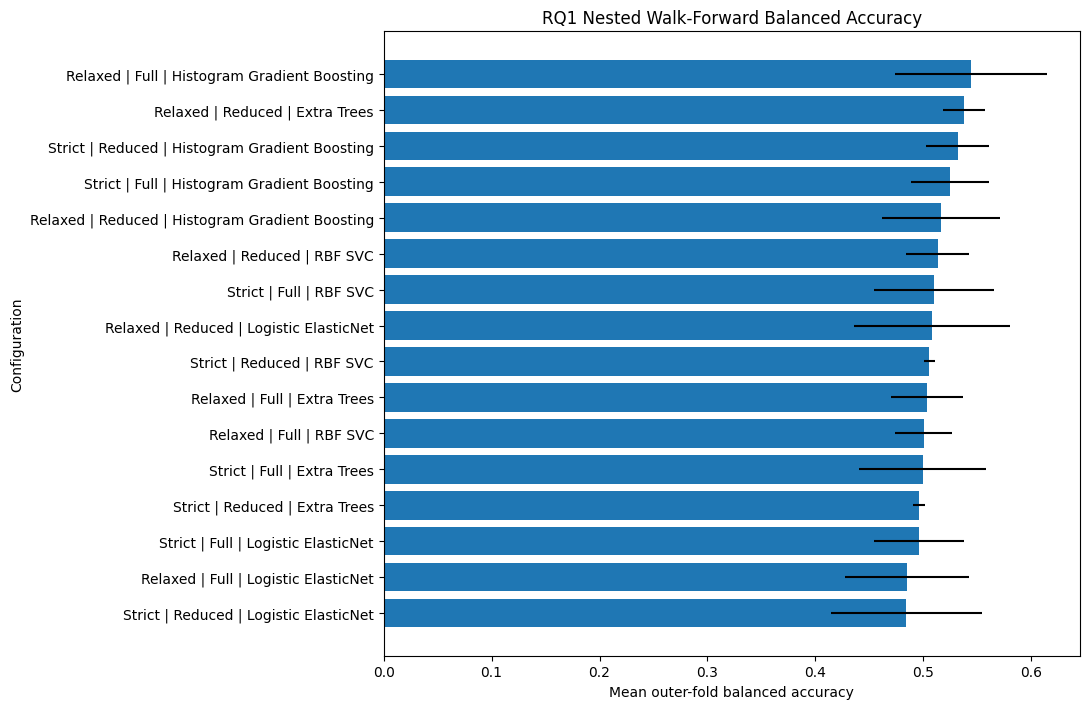

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\figures\rq1_nested_balanced_accuracy.png


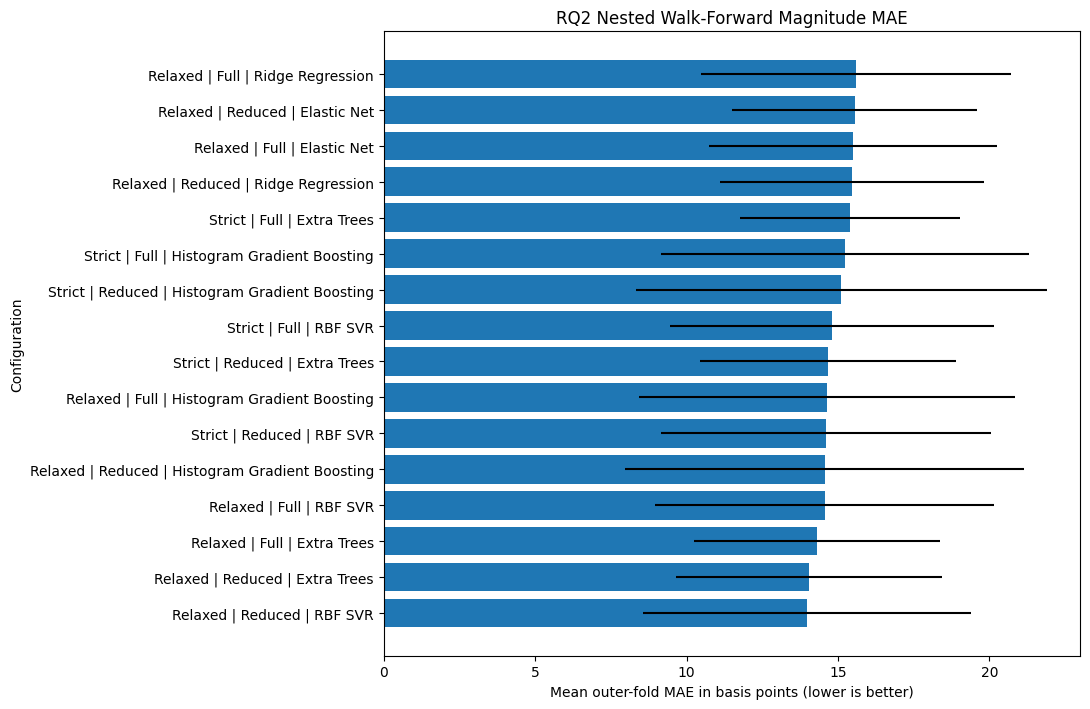

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\figures\rq2_nested_mae.png


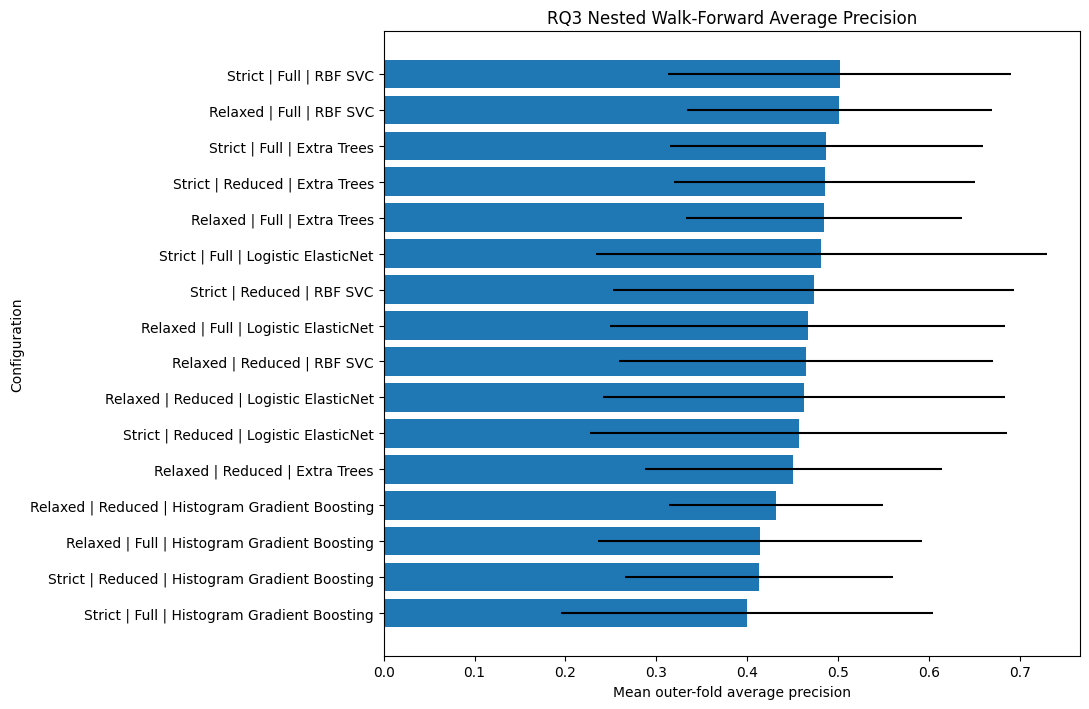

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\figures\rq3_nested_average_precision.png


In [12]:
# I use this cell for ranking and stability charts.
def nested_ranking_plot(
    results: pd.DataFrame,
    metric: str,
    variability: str,
    title: str,
    xlabel: str,
    filename: str,
    higher_is_better: bool,
    top_n: int = 16,
):
    plot_data = results.copy()

    plot_data["configuration"] = (
        plot_data["dataset_variant"]
        + " | "
        + plot_data["feature_set"]
        + " | "
        + plot_data["model"]
    )

    plot_data = plot_data.sort_values(
        metric,
        ascending=not higher_is_better,
    ).head(top_n)

    plot_data = plot_data.sort_values(metric)

    fig, ax = plt.subplots(
        figsize=(11, max(6, len(plot_data) * 0.45))
    )

    ax.barh(
        plot_data["configuration"],
        plot_data[metric],
        xerr=plot_data[variability],
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Configuration")

    path = save_figure(fig, filename)
    plt.show()

    print("Saved:", path)


nested_ranking_plot(
    rq1_tuning_summary,
    metric="outer_balanced_accuracy_mean",
    variability="outer_balanced_accuracy_std",
    title="RQ1 Nested Walk-Forward Balanced Accuracy",
    xlabel="Mean outer-fold balanced accuracy",
    filename="rq1_nested_balanced_accuracy.png",
    higher_is_better=True,
)

nested_ranking_plot(
    rq2_tuning_summary,
    metric="outer_mae_bps_mean",
    variability="outer_mae_bps_std",
    title="RQ2 Nested Walk-Forward Magnitude MAE",
    xlabel="Mean outer-fold MAE in basis points (lower is better)",
    filename="rq2_nested_mae.png",
    higher_is_better=False,
)

nested_ranking_plot(
    rq3_tuning_summary,
    metric="outer_average_precision_mean",
    variability="outer_average_precision_std",
    title="RQ3 Nested Walk-Forward Average Precision",
    xlabel="Mean outer-fold average precision",
    filename="rq3_nested_average_precision.png",
    higher_is_better=True,
)

## 12. Select tuned development winners

Selection uses nested outer-fold performance only.

The selected configuration is then retuned on the full Train + Validation development period. This produces a final parameter set, but the original test period remains disabled by default.

In [13]:
# I use this cell for select tuned development winners.
rq1_winner = rq1_tuning_summary.iloc[0].to_dict()
rq2_winner = rq2_tuning_summary.iloc[0].to_dict()
rq3_winner = rq3_tuning_summary.iloc[0].to_dict()

tuned_winners = pd.DataFrame(
    [
        {
            "research_question": "RQ1 Direction",
            "dataset_variant": rq1_winner[
                "dataset_variant"
            ],
            "feature_set": rq1_winner["feature_set"],
            "model": rq1_winner["model"],
            "primary_metric": "Balanced accuracy",
            "outer_score": rq1_winner[
                "outer_balanced_accuracy_mean"
            ],
            "outer_standard_deviation": rq1_winner[
                "outer_balanced_accuracy_std"
            ],
        },
        {
            "research_question": "RQ2 Magnitude",
            "dataset_variant": rq2_winner[
                "dataset_variant"
            ],
            "feature_set": rq2_winner["feature_set"],
            "model": rq2_winner["model"],
            "primary_metric": "MAE in basis points",
            "outer_score": rq2_winner[
                "outer_mae_bps_mean"
            ],
            "outer_standard_deviation": rq2_winner[
                "outer_mae_bps_std"
            ],
        },
        {
            "research_question": "RQ3 Large Movement",
            "dataset_variant": rq3_winner[
                "dataset_variant"
            ],
            "feature_set": rq3_winner["feature_set"],
            "model": rq3_winner["model"],
            "primary_metric": "Average precision",
            "outer_score": rq3_winner[
                "outer_average_precision_mean"
            ],
            "outer_standard_deviation": rq3_winner[
                "outer_average_precision_std"
            ],
        },
    ]
)

display(tuned_winners)

TUNED_WINNERS_PATH = (
    TABLE_ROOT
    / "nested_tuned_winners.csv"
)

tuned_winners.to_csv(
    TUNED_WINNERS_PATH,
    index=False,
)

print("Saved:", TUNED_WINNERS_PATH)

,research_question,dataset_variant,feature_set,model,primary_metric,outer_score,outer_standard_deviation
0,RQ1 Direction,Relaxed,Full,Histogram Gradient Boosting,Balanced accuracy,0.543904,0.070448
1,RQ2 Magnitude,Relaxed,Reduced,RBF SVR,MAE in basis points,13.967479,5.406184
2,RQ3 Large Movement,Strict,Full,RBF SVC,Average precision,0.501411,0.189125


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\tables\nested_tuned_winners.csv


## 13. Final development-period searches

This stage derives a reproducible final parameter configuration for each research question.

It still uses only Train + Validation.

In [14]:
# I use this cell for final development-period searches.
def final_development_search(
    winner: dict,
    task_type: str,
    target_column: str,
    scoring: str,
):
    variant_name = winner["dataset_variant"]
    feature_set_name = winner["feature_set"]
    model_name = winner["model"]

    frame = development_frame(
        datasets[variant_name]
    )

    features = FEATURE_SETS[
        feature_set_name
    ]

    X = frame[features]
    y = frame[target_column]

    if task_type == "classification":
        specification = (
            CLASSIFICATION_SEARCH_SPACES[
                model_name
            ]
        )
    elif task_type == "regression":
        specification = (
            REGRESSION_SEARCH_SPACES[
                model_name
            ]
        )
    else:
        raise ValueError(task_type)

    search = RandomizedSearchCV(
        estimator=clone(
            specification["estimator"]
        ),
        param_distributions=(
            specification["parameters"]
        ),
        n_iter=max(
            N_RANDOM_SEARCH_ITERATIONS * 2,
            12,
        ),
        scoring=scoring,
        cv=TimeSeriesSplit(
            n_splits=max(
                INNER_SPLITS + 1,
                4,
            )
        ),
        refit=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=False,
    )

    search.fit(X, y)

    return {
        "dataset_variant": variant_name,
        "feature_set": feature_set_name,
        "features": features,
        "model": model_name,
        "best_parameters": search.best_params_,
        "best_inner_score": search.best_score_,
        "estimator": search.best_estimator_,
    }


rq1_final_development = final_development_search(
    rq1_winner,
    task_type="classification",
    target_column="target_up",
    scoring="balanced_accuracy",
)

rq2_final_development = final_development_search(
    rq2_winner,
    task_type="regression",
    target_column="target_magnitude_bps",
    scoring="neg_mean_absolute_error",
)

rq3_final_development = final_development_search(
    rq3_winner,
    task_type="classification",
    target_column="target_large_move",
    scoring="average_precision",
)

final_configuration_manifest = {
    "RQ1": {
        key: value
        for key, value in rq1_final_development.items()
        if key != "estimator"
    },
    "RQ2": {
        key: value
        for key, value in rq2_final_development.items()
        if key != "estimator"
    },
    "RQ3": {
        key: value
        for key, value in rq3_final_development.items()
        if key != "estimator"
    },
    "large_move_threshold_bps": (
        LARGE_MOVE_THRESHOLD_BPS
    ),
    "outer_splits": OUTER_SPLITS,
    "inner_splits": INNER_SPLITS,
    "random_search_iterations": (
        N_RANDOM_SEARCH_ITERATIONS
    ),
    "primary_evidence": (
        "Nested expanding-window development-period performance"
    ),
    "existing_test_status": (
        "Previously viewed in baseline notebook; not fresh"
    ),
}

CONFIGURATION_PATH = (
    TUNING_ROOT
    / "final_tuned_configuration_manifest.json"
)

with open(
    CONFIGURATION_PATH,
    "w",
    encoding="utf-8",
) as configuration_file:
    json.dump(
        final_configuration_manifest,
        configuration_file,
        indent=2,
        default=str,
    )

print(
    json.dumps(
        final_configuration_manifest,
        indent=2,
        default=str,
    )
)

print("Saved:", CONFIGURATION_PATH)

{
  "RQ1": {
    "dataset_variant": "Relaxed",
    "feature_set": "Full",
    "features": [
      "ret_open_to_1500",
      "ret_last_15m",
      "ret_last_30m",
      "ret_last_60m",
      "momentum_accel_60m_vs_prior",
      "vix_level_1500",
      "vix_ret_last_15m",
      "vix_ret_last_30m",
      "vix_ret_last_60m",
      "realized_vol_30m",
      "realized_vol_60m",
      "realized_vol_120m",
      "rv_open_to_1500",
      "spy_volume_last_30m",
      "spy_volume_last_60m",
      "spy_cum_volume_to_1500",
      "spy_volume_accel_60m_vs_avg",
      "spy_dist_from_vwap_pct",
      "position_in_day_range",
      "dist_from_day_high_pct",
      "dist_from_day_low_pct",
      "atr_pct_open_to_1500"
    ],
    "model": "Histogram Gradient Boosting",
    "best_parameters": {
      "model__l2_regularization": 2.990542595437359,
      "model__learning_rate": 0.06669254439997736,
      "model__max_bins": 64,
      "model__max_iter": 383,
      "model__max_leaf_nodes": 16,
      "model__min

## 14. Save the selected development models

I keep model saving behind one visible switch. When it is enabled, I save only the three selected RQ1–RQ3 pipelines fitted on the chronological Train + Validation development period. I calculate the RQ1 and RQ3 thresholds from expanding-window development predictions, never from Test observations. Each canonical file is atomically replaced on a rerun and immediately reloaded for a small prediction check.

In [15]:
# I enable this only when I want to replace the canonical development artifacts.
SAVE_MODEL_ARTIFACTS = True

import platform
import sys

import joblib
import sklearn

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.model_artifacts import (
    save_sklearn_artifact,
    write_model_manifest,
)

CLASSICAL_MODEL_ROOT = PROJECT_ROOT / "models" / "classical"


def chronological_development_threshold(
    final_configuration: dict,
    target_column: str,
    objective: str,
):
    """Choose a threshold from expanding-window development predictions only."""
    frame = development_frame(
        datasets[final_configuration["dataset_variant"]]
    )
    features = final_configuration["features"]
    true_values, scores = inner_time_series_scores(
        clone(final_configuration["estimator"]),
        frame[features],
        frame[target_column],
        n_splits=max(INNER_SPLITS + 1, 4),
    )
    threshold, objective_value = select_threshold(
        true_values,
        scores,
        objective=objective,
    )
    return float(threshold), float(objective_value)


def classical_artifact_metadata(
    research_question: str,
    target_column: str,
    final_configuration: dict,
    threshold,
    threshold_objective,
    threshold_objective_value,
):
    frame = development_frame(
        datasets[final_configuration["dataset_variant"]]
    )
    return {
        "research_question": research_question,
        "target": target_column,
        "source_notebook": "08_hyperparameters_tuning_extended_robustness.ipynb",
        "model_family": final_configuration["model"],
        "dataset_variant": final_configuration["dataset_variant"],
        "feature_set": final_configuration["feature_set"],
        "features": final_configuration["features"],
        "training_start": str(frame["session_date"].min()),
        "training_end": str(frame["session_date"].max()),
        "training_rows": int(len(frame)),
        "included_splits": ["Train", "Validation"],
        "excluded_splits": ["Test", "fresh post-2026-07-17 holdout"],
        "classification_threshold": threshold,
        "threshold_objective": threshold_objective,
        "threshold_objective_value": threshold_objective_value,
        "best_parameters": final_configuration["best_parameters"],
        "best_inner_score": final_configuration["best_inner_score"],
        "estimator_class": type(final_configuration["estimator"]).__name__,
        "library_versions": {
            "python": platform.python_version(),
            "numpy": np.__version__,
            "pandas": pd.__version__,
            "scikit_learn": sklearn.__version__,
            "joblib": joblib.__version__,
        },
    }


if SAVE_MODEL_ARTIFACTS:
    rq1_threshold, rq1_threshold_score = chronological_development_threshold(
        rq1_final_development,
        "target_up",
        "balanced_accuracy",
    )
    rq3_threshold, rq3_threshold_score = chronological_development_threshold(
        rq3_final_development,
        "target_large_move",
        "f1",
    )

    artifact_specs = [
        (
            "RQ1",
            "target_up",
            rq1_final_development,
            "rq1_direction.joblib",
            rq1_threshold,
            "balanced_accuracy",
            rq1_threshold_score,
        ),
        (
            "RQ2",
            "target_magnitude_bps",
            rq2_final_development,
            "rq2_magnitude.joblib",
            None,
            None,
            None,
        ),
        (
            "RQ3",
            "target_large_move",
            rq3_final_development,
            "rq3_large_move.joblib",
            rq3_threshold,
            "f1",
            rq3_threshold_score,
        ),
    ]

    classical_artifacts = []
    for (
        research_question,
        target_column,
        final_configuration,
        filename,
        threshold,
        threshold_objective,
        threshold_objective_value,
    ) in artifact_specs:
        frame = development_frame(
            datasets[final_configuration["dataset_variant"]]
        )
        verification_input = frame[
            final_configuration["features"]
        ].iloc[:3]
        record = save_sklearn_artifact(
            final_configuration["estimator"],
            CLASSICAL_MODEL_ROOT / filename,
            classical_artifact_metadata(
                research_question,
                target_column,
                final_configuration,
                threshold,
                threshold_objective,
                threshold_objective_value,
            ),
            relative_to=PROJECT_ROOT,
            verification_input=verification_input,
        )
        classical_artifacts.append(record)
        print("Saved and reloaded:", record["artifact_path"])

    classical_manifest_path = write_model_manifest(
        CLASSICAL_MODEL_ROOT / "manifest.json",
        classical_artifacts,
        metadata={
            "artifact_set": "canonical RQ1-RQ3 classical development models",
            "fit_policy": "Train + Validation only",
            "replacement_policy": "atomic canonical overwrite",
        },
    )
    print("Saved:", classical_manifest_path)
else:
    print("Model saving is disabled; no artifact files were created.")

Saved and reloaded: models/classical/rq1_direction.joblib
Saved and reloaded: models/classical/rq2_magnitude.joblib
Saved and reloaded: models/classical/rq3_large_move.joblib
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\models\classical\manifest.json


## 15. Selected-winner robustness diagnostics

This section reruns only the three selected model families inside the same nested outer folds. It adds:

- fold-matched rule and dummy benchmarks;
- the corrected RQ3 prevalence and average-precision lift comparison;
- permutation importance on every outer test fold;
- VIX, realised-volatility, and pre-15:00 trend regime analysis;
- RQ1 confidence-versus-coverage analysis.

Regime thresholds are estimated from each outer training fold and then applied to its later outer test fold. Confidence ranks are also calculated separately within each outer fold so that probability and decision-function scales remain comparable. These analyses are descriptive robustness checks on the selected winners; they do not replace evaluation on the new untouched final holdout.

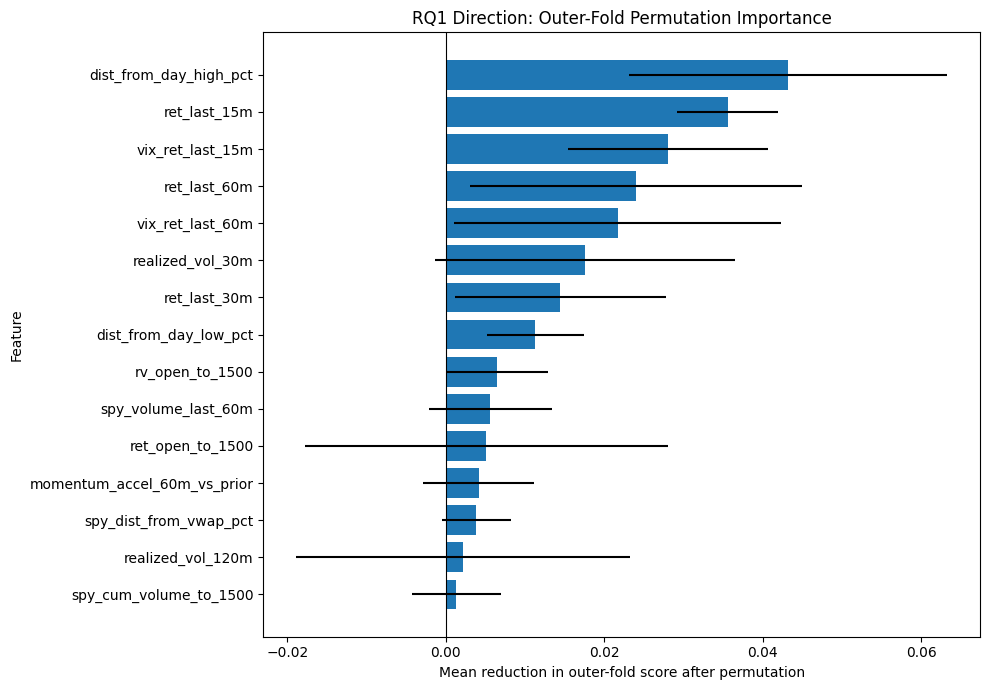

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\figures\rq1_outer_fold_permutation_importance.png


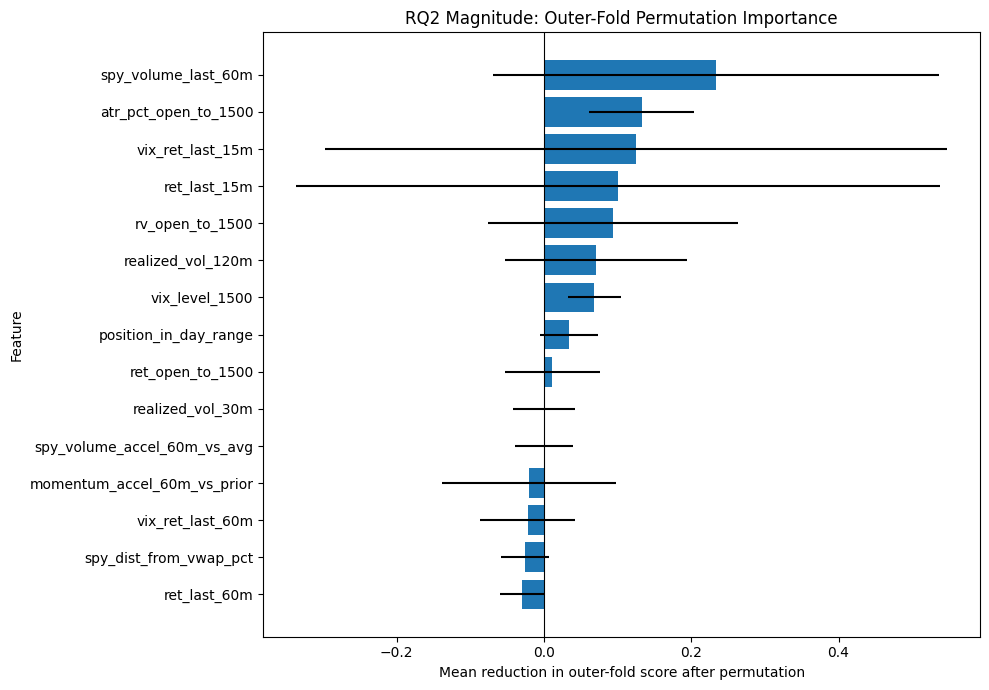

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\figures\rq2_outer_fold_permutation_importance.png


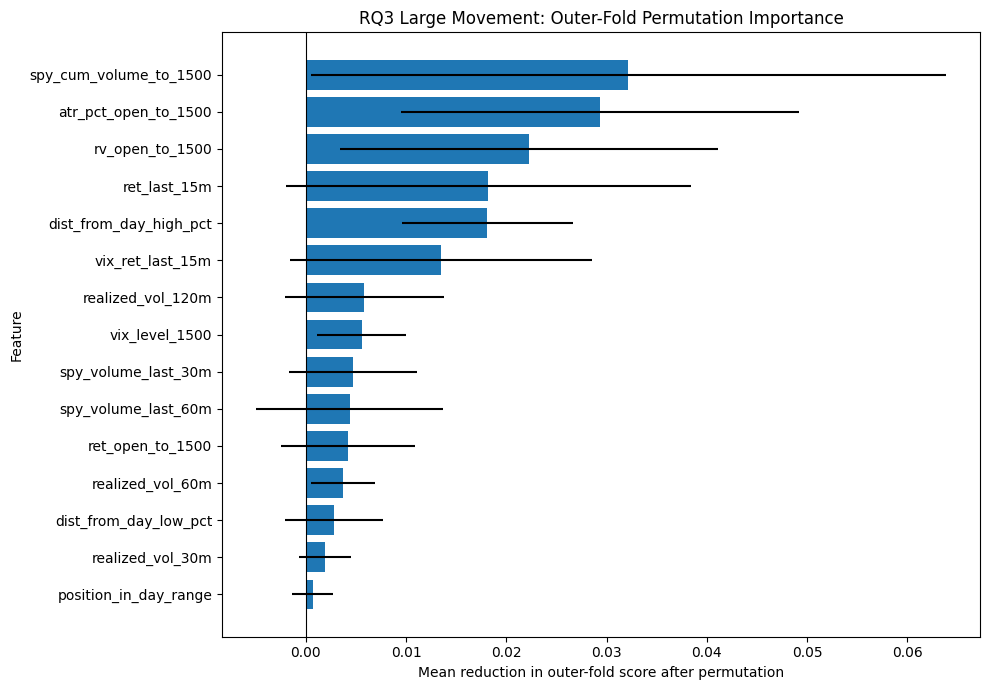

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\figures\rq3_outer_fold_permutation_importance.png


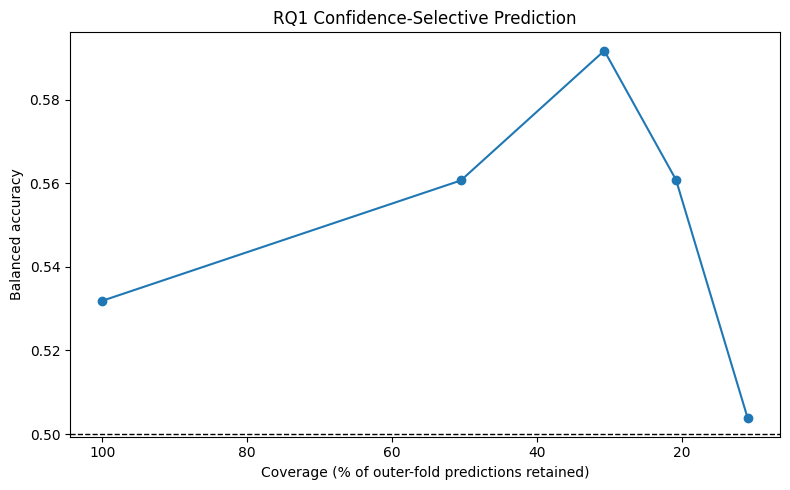

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\hyperparameter_tuning\figures\rq1_selective_prediction_coverage.png
Fold-matched benchmark summary


,research_question,benchmark,metric,outer_folds,model_score_mean,model_score_std,benchmark_score_mean,benchmark_score_std,absolute_improvement_mean,absolute_improvement_std,relative_improvement_mean
0,RQ1 Direction,15-minute mean reversion,Balanced accuracy,3,0.543904,0.070448,0.558583,0.080984,-0.014679,0.132623,-0.004305
1,RQ1 Direction,15-minute momentum,Balanced accuracy,3,0.543904,0.070448,0.441417,0.080984,0.102488,0.073850,0.247675
2,RQ1 Direction,60-minute mean reversion,Balanced accuracy,3,0.543904,0.070448,0.569173,0.034795,-0.025268,0.058712,-0.044808
3,RQ1 Direction,60-minute momentum,Balanced accuracy,3,0.543904,0.070448,0.430827,0.034795,0.113077,0.094341,0.273404
4,RQ1 Direction,Previous-session direction,Balanced accuracy,3,0.543904,0.070448,0.468287,0.021522,0.075618,0.049917,0.158577
5,RQ1 Direction,Training majority,Balanced accuracy,3,0.543904,0.070448,0.500000,0.000000,0.043904,0.070448,0.087809
6,RQ2 Magnitude,Outer-training median,MAE (basis points),3,13.967479,5.406184,15.287210,7.750523,1.319731,2.344707,0.049719
7,RQ3 Large Movement,Outer-test prevalence,Average precision,3,0.501411,0.189125,0.275362,0.169904,0.226049,0.051959,1.034181


Feature-importance stability


,research_question,feature,feature_group,outer_folds,mean_importance,between_fold_std,mean_within_fold_std,positive_fold_share,top_five_fold_count
0,RQ1 Direction,dist_from_day_high_pct,Price position,3,0.043173,0.020103,0.022573,1.000000,3
1,RQ1 Direction,ret_last_15m,SPX momentum,3,0.035586,0.006372,0.014949,1.000000,3
2,RQ1 Direction,vix_ret_last_15m,VIX,3,0.028016,0.012606,0.022498,1.000000,3
3,RQ1 Direction,ret_last_60m,SPX momentum,3,0.023991,0.020918,0.015618,0.666667,1
4,RQ1 Direction,vix_ret_last_60m,VIX,3,0.021676,0.020641,0.012650,1.000000,1
5,RQ1 Direction,realized_vol_30m,Realised volatility,3,0.017517,0.018903,0.019634,1.000000,1
6,RQ1 Direction,ret_last_30m,SPX momentum,3,0.014443,0.013332,0.011899,1.000000,1
7,RQ1 Direction,dist_from_day_low_pct,Price position,3,0.011314,0.006112,0.011752,1.000000,1
8,RQ1 Direction,rv_open_to_1500,Realised volatility,3,0.006480,0.006460,0.007636,1.000000,0
9,RQ1 Direction,spy_volume_last_60m,SPY volume,3,0.005635,0.007736,0.013464,0.666667,0


Feature-group stability


,research_question,feature_group,mean_importance_per_feature,between_fold_std,positive_fold_share
0,RQ1 Direction,SPX momentum,0.016654,0.007596,1.000000
1,RQ1 Direction,Price position,0.011917,0.007234,1.000000
2,RQ1 Direction,VIX,0.007812,0.013804,0.666667
3,RQ1 Direction,Realised volatility,0.004011,0.011788,0.666667
4,RQ1 Direction,SPY volume,0.000172,0.009848,0.666667
5,RQ1 Direction,True range,-0.001550,0.024023,0.333333
6,RQ2 Magnitude,True range,0.133072,0.071258,1.000000
7,RQ2 Magnitude,SPY volume,0.116424,0.170710,0.666667
8,RQ2 Magnitude,VIX,0.057112,0.126099,0.666667
9,RQ2 Magnitude,Realised volatility,0.054699,0.111582,0.666667


Regime analysis


,research_question,regime_type,regime,sessions,minimum_sample_met,first_date,last_date,balanced_accuracy,accuracy,mcc,positive_rate,mae_bps,rmse_bps,r2,spearman,average_precision,prevalence,average_precision_lift,precision,recall,f1
0,RQ1 Direction,VIX regime,High,100,True,2024-12-19,2026-03-20,0.501610,0.500000,0.003213,0.460000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RQ1 Direction,VIX regime,Low,85,True,2024-12-16,2026-01-28,0.596175,0.600000,0.197221,0.482353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RQ1 Direction,VIX regime,Medium,118,True,2024-12-18,2026-02-26,0.509511,0.525424,0.019401,0.432203,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RQ1 Direction,Realised-volatility regime,High,114,True,2024-12-18,2026-03-20,0.535406,0.535088,0.070846,0.491228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RQ1 Direction,Realised-volatility regime,Low,98,True,2024-12-16,2026-03-04,0.603448,0.622449,0.209764,0.408163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,RQ1 Direction,Realised-volatility regime,Medium,91,True,2024-12-23,2026-03-17,0.440476,0.450549,-0.122678,0.461538,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,RQ1 Direction,Pre-15:00 trend,Negative pre-15:00 return,145,True,2024-12-17,2026-03-20,0.544330,0.544828,0.089603,0.496552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,RQ1 Direction,Pre-15:00 trend,Positive pre-15:00 return,158,True,2024-12-16,2026-03-19,0.520751,0.531646,0.041339,0.417722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,RQ2 Magnitude,VIX regime,High,100,True,2024-12-19,2026-03-20,NaN,NaN,NaN,NaN,22.566537,35.511385,-0.109818,0.121200,NaN,NaN,NaN,NaN,NaN,NaN
9,RQ2 Magnitude,VIX regime,Low,85,True,2024-12-16,2026-01-28,NaN,NaN,NaN,NaN,7.026816,9.212611,-0.112219,0.103127,NaN,NaN,NaN,NaN,NaN,NaN


RQ1 selective-prediction analysis


,requested_coverage,realised_coverage,sessions,balanced_accuracy,accuracy,precision,recall,f1,mcc,positive_rate,mean_confidence_percentile
0,1.000000,1.000000,303,0.531884,0.537954,0.492308,0.463768,0.477612,0.064164,0.455446,0.504950
1,0.500000,0.504950,153,0.560664,0.568627,0.492537,0.507692,0.500000,0.120886,0.424837,0.752475
2,0.300000,0.306931,93,0.591699,0.602151,0.500000,0.540541,0.519481,0.181310,0.397849,0.851485
3,0.200000,0.207921,63,0.560811,0.571429,0.481481,0.500000,0.490566,0.120994,0.412698,0.900990
4,0.100000,0.108911,33,0.503759,0.515152,0.428571,0.428571,0.428571,0.007519,0.424242,0.950495


In [16]:
# Configuration for post-selection robustness diagnostics.
PERMUTATION_REPEATS = 20
MIN_REGIME_SESSIONS = 10
SELECTIVE_COVERAGES = [1.00, 0.50, 0.30, 0.20, 0.10]

FEATURE_GROUPS = {
    "ret_open_to_1500": "SPX momentum",
    "ret_last_15m": "SPX momentum",
    "ret_last_30m": "SPX momentum",
    "ret_last_60m": "SPX momentum",
    "momentum_accel_60m_vs_prior": "SPX momentum",
    "vix_level_1500": "VIX",
    "vix_ret_last_15m": "VIX",
    "vix_ret_last_30m": "VIX",
    "vix_ret_last_60m": "VIX",
    "realized_vol_30m": "Realised volatility",
    "realized_vol_60m": "Realised volatility",
    "realized_vol_120m": "Realised volatility",
    "rv_open_to_1500": "Realised volatility",
    "spy_volume_last_30m": "SPY volume",
    "spy_volume_last_60m": "SPY volume",
    "spy_cum_volume_to_1500": "SPY volume",
    "spy_volume_accel_60m_vs_avg": "SPY volume",
    "spy_dist_from_vwap_pct": "Price position",
    "position_in_day_range": "Price position",
    "dist_from_day_high_pct": "Price position",
    "dist_from_day_low_pct": "Price position",
    "atr_pct_open_to_1500": "True range",
}


def _selected_specification(
    winner: dict,
    task_type: str,
):
    model_name = winner["model"]

    if task_type == "classification":
        return CLASSIFICATION_SEARCH_SPACES[model_name]

    if task_type == "regression":
        return REGRESSION_SEARCH_SPACES[model_name]

    raise ValueError(f"Unsupported task type: {task_type}")


def _relative_improvement(
    model_score: float,
    benchmark_score: float,
    higher_is_better: bool,
) -> float:
    if not np.isfinite(benchmark_score) or benchmark_score == 0:
        return np.nan

    if higher_is_better:
        return (model_score - benchmark_score) / abs(benchmark_score)

    return (benchmark_score - model_score) / abs(benchmark_score)


def _three_level_regime(
    values: pd.Series,
    lower_cutoff: float,
    upper_cutoff: float,
) -> pd.Series:
    return pd.Series(
        np.select(
            [
                values <= lower_cutoff,
                values >= upper_cutoff,
            ],
            ["Low", "High"],
            default="Medium",
        ),
        index=values.index,
        dtype="object",
    )


def _rq1_benchmark_predictions(
    development: pd.DataFrame,
    outer_train_index: np.ndarray,
    outer_test_index: np.ndarray,
) -> dict[str, np.ndarray]:
    y_outer_train = development.iloc[outer_train_index][
        "target_up"
    ].astype(int)

    majority_class = int(y_outer_train.mode().iloc[0])

    previous_direction = (
        development["target_up"]
        .shift(1)
        .iloc[outer_test_index]
        .fillna(majority_class)
        .astype(int)
        .to_numpy()
    )

    test_rows = development.iloc[outer_test_index]

    return {
        "Training majority": np.full(
            len(outer_test_index),
            majority_class,
            dtype=int,
        ),
        "Previous-session direction": previous_direction,
        "15-minute momentum": (
            test_rows["ret_last_15m"] >= 0
        ).astype(int).to_numpy(),
        "15-minute mean reversion": (
            test_rows["ret_last_15m"] < 0
        ).astype(int).to_numpy(),
        "60-minute momentum": (
            test_rows["ret_last_60m"] >= 0
        ).astype(int).to_numpy(),
        "60-minute mean reversion": (
            test_rows["ret_last_60m"] < 0
        ).astype(int).to_numpy(),
    }


def selected_winner_outer_diagnostics(
    winner: dict,
    research_question: str,
    task_type: str,
    target_column: str,
    search_scoring: str,
    threshold_objective: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Re-run the selected model family within each outer fold.

    This preserves the original nested structure while collecting
    session-level predictions, fold-matched benchmarks, and permutation
    importance on each outer test fold.
    """
    variant_name = winner["dataset_variant"]
    feature_set_name = winner["feature_set"]
    features = FEATURE_SETS[feature_set_name]

    development = development_frame(
        datasets[variant_name]
    )

    X = development[features]
    y = development[target_column]

    if task_type == "classification":
        y = y.astype(int)

    specification = _selected_specification(
        winner,
        task_type,
    )

    outer_splitter = TimeSeriesSplit(
        n_splits=OUTER_SPLITS
    )

    prediction_rows = []
    benchmark_rows = []
    importance_rows = []

    for outer_fold, (
        outer_train_index,
        outer_test_index,
    ) in enumerate(
        outer_splitter.split(X),
        start=1,
    ):
        X_outer_train = X.iloc[outer_train_index]
        y_outer_train = y.iloc[outer_train_index]
        X_outer_test = X.iloc[outer_test_index]
        y_outer_test = y.iloc[outer_test_index]

        inner_splitter = TimeSeriesSplit(
            n_splits=INNER_SPLITS
        )

        search = RandomizedSearchCV(
            estimator=clone(
                specification["estimator"]
            ),
            param_distributions=(
                specification["parameters"]
            ),
            n_iter=N_RANDOM_SEARCH_ITERATIONS,
            scoring=search_scoring,
            cv=inner_splitter,
            refit=True,
            random_state=RANDOM_STATE + outer_fold,
            n_jobs=-1,
            return_train_score=False,
        )

        search.fit(
            X_outer_train,
            y_outer_train,
        )

        best_estimator = search.best_estimator_
        threshold = np.nan

        if task_type == "classification":
            inner_y, inner_scores = inner_time_series_scores(
                best_estimator,
                X_outer_train.reset_index(drop=True),
                y_outer_train.reset_index(drop=True),
                n_splits=INNER_SPLITS,
            )

            threshold, _ = select_threshold(
                inner_y,
                inner_scores,
                objective=threshold_objective,
            )

            outer_scores = model_scores(
                best_estimator,
                X_outer_test,
            )

            outer_predictions = (
                outer_scores >= threshold
            ).astype(int)

            model_metrics = classification_metric_bundle(
                y_outer_test,
                outer_predictions,
                outer_scores,
            )
        else:
            outer_scores = best_estimator.predict(
                X_outer_test
            )
            outer_predictions = outer_scores
            model_metrics = regression_metric_bundle(
                y_outer_test,
                outer_predictions,
            )

        outer_test_rows = development.iloc[
            outer_test_index
        ].copy()

        vix_lower, vix_upper = (
            development.iloc[outer_train_index][
                "vix_level_1500"
            ].quantile([1 / 3, 2 / 3])
        )

        rv_lower, rv_upper = (
            development.iloc[outer_train_index][
                "realized_vol_60m"
            ].quantile([1 / 3, 2 / 3])
        )

        vix_regime = _three_level_regime(
            outer_test_rows["vix_level_1500"],
            float(vix_lower),
            float(vix_upper),
        )

        realized_vol_regime = _three_level_regime(
            outer_test_rows["realized_vol_60m"],
            float(rv_lower),
            float(rv_upper),
        )

        trend_regime = np.where(
            outer_test_rows["ret_open_to_1500"] >= 0,
            "Positive pre-15:00 return",
            "Negative pre-15:00 return",
        )

        if task_type == "classification":
            confidence_raw = np.abs(
                outer_scores - threshold
            )
            confidence_percentile = (
                pd.Series(confidence_raw)
                .rank(method="average", pct=True)
                .to_numpy()
            )
            score_percentile = (
                pd.Series(outer_scores)
                .rank(method="average", pct=True)
                .to_numpy()
            )
        else:
            confidence_raw = np.full(
                len(outer_test_index),
                np.nan,
            )
            confidence_percentile = np.full(
                len(outer_test_index),
                np.nan,
            )
            score_percentile = (
                pd.Series(outer_scores)
                .rank(method="average", pct=True)
                .to_numpy()
            )

        for row_position, source_index in enumerate(
            outer_test_index
        ):
            prediction_rows.append(
                {
                    "research_question": research_question,
                    "dataset_variant": variant_name,
                    "feature_set": feature_set_name,
                    "model": winner["model"],
                    "outer_fold": outer_fold,
                    "session_date": development.iloc[
                        source_index
                    ]["session_date"],
                    "y_true": float(
                        y_outer_test.iloc[row_position]
                    ),
                    "prediction": float(
                        outer_predictions[row_position]
                    ),
                    "score": float(
                        outer_scores[row_position]
                    ),
                    "threshold": float(threshold)
                    if np.isfinite(threshold)
                    else np.nan,
                    "confidence_raw": float(
                        confidence_raw[row_position]
                    )
                    if np.isfinite(
                        confidence_raw[row_position]
                    )
                    else np.nan,
                    "confidence_percentile": float(
                        confidence_percentile[row_position]
                    )
                    if np.isfinite(
                        confidence_percentile[row_position]
                    )
                    else np.nan,
                    "score_percentile": float(
                        score_percentile[row_position]
                    ),
                    "vix_regime": vix_regime.iloc[
                        row_position
                    ],
                    "realized_vol_regime": (
                        realized_vol_regime.iloc[
                            row_position
                        ]
                    ),
                    "intraday_trend_regime": (
                        trend_regime[row_position]
                    ),
                }
            )

        test_start = outer_test_rows[
            "session_date"
        ].min()
        test_end = outer_test_rows[
            "session_date"
        ].max()

        if research_question == "RQ1 Direction":
            model_score = model_metrics[
                "balanced_accuracy"
            ]

            benchmarks = _rq1_benchmark_predictions(
                development,
                outer_train_index,
                outer_test_index,
            )

            for benchmark_name, benchmark_predictions in (
                benchmarks.items()
            ):
                benchmark_score = balanced_accuracy_score(
                    y_outer_test,
                    benchmark_predictions,
                )

                benchmark_rows.append(
                    {
                        "research_question": research_question,
                        "outer_fold": outer_fold,
                        "outer_test_start": test_start,
                        "outer_test_end": test_end,
                        "benchmark": benchmark_name,
                        "metric": "Balanced accuracy",
                        "model_score": model_score,
                        "benchmark_score": benchmark_score,
                        "absolute_improvement": (
                            model_score - benchmark_score
                        ),
                        "relative_improvement": (
                            _relative_improvement(
                                model_score,
                                benchmark_score,
                                higher_is_better=True,
                            )
                        ),
                    }
                )

        elif research_question == "RQ2 Magnitude":
            model_score = model_metrics["mae_bps"]
            dummy_value = float(
                y_outer_train.median()
            )
            dummy_predictions = np.full(
                len(y_outer_test),
                dummy_value,
            )
            benchmark_score = mean_absolute_error(
                y_outer_test,
                dummy_predictions,
            )

            benchmark_rows.append(
                {
                    "research_question": research_question,
                    "outer_fold": outer_fold,
                    "outer_test_start": test_start,
                    "outer_test_end": test_end,
                    "benchmark": "Outer-training median",
                    "metric": "MAE (basis points)",
                    "model_score": model_score,
                    "benchmark_score": benchmark_score,
                    "absolute_improvement": (
                        benchmark_score - model_score
                    ),
                    "relative_improvement": (
                        _relative_improvement(
                            model_score,
                            benchmark_score,
                            higher_is_better=False,
                        )
                    ),
                }
            )

        elif research_question == "RQ3 Large Movement":
            model_score = model_metrics[
                "average_precision"
            ]
            benchmark_score = float(
                y_outer_test.mean()
            )

            benchmark_rows.append(
                {
                    "research_question": research_question,
                    "outer_fold": outer_fold,
                    "outer_test_start": test_start,
                    "outer_test_end": test_end,
                    "benchmark": "Outer-test prevalence",
                    "metric": "Average precision",
                    "model_score": model_score,
                    "benchmark_score": benchmark_score,
                    "absolute_improvement": (
                        model_score - benchmark_score
                    ),
                    "relative_improvement": (
                        _relative_improvement(
                            model_score,
                            benchmark_score,
                            higher_is_better=True,
                        )
                    ),
                }
            )

        if research_question == "RQ1 Direction":
            def importance_scorer(
                fitted_estimator,
                X_evaluation,
                y_evaluation,
            ):
                evaluation_scores = model_scores(
                    fitted_estimator,
                    X_evaluation,
                )
                evaluation_predictions = (
                    evaluation_scores >= threshold
                ).astype(int)
                return balanced_accuracy_score(
                    y_evaluation,
                    evaluation_predictions,
                )

        elif research_question == "RQ3 Large Movement":
            def importance_scorer(
                fitted_estimator,
                X_evaluation,
                y_evaluation,
            ):
                evaluation_scores = model_scores(
                    fitted_estimator,
                    X_evaluation,
                )
                return safe_average_precision(
                    y_evaluation,
                    evaluation_scores,
                )

        else:
            def importance_scorer(
                fitted_estimator,
                X_evaluation,
                y_evaluation,
            ):
                evaluation_predictions = (
                    fitted_estimator.predict(
                        X_evaluation
                    )
                )
                return -mean_absolute_error(
                    y_evaluation,
                    evaluation_predictions,
                )

        permutation = permutation_importance(
            best_estimator,
            X_outer_test,
            y_outer_test,
            scoring=importance_scorer,
            n_repeats=PERMUTATION_REPEATS,
            random_state=(
                RANDOM_STATE + 1_000 + outer_fold
            ),
            n_jobs=1,
        )

        for feature, mean_importance, std_importance in zip(
            features,
            permutation.importances_mean,
            permutation.importances_std,
        ):
            importance_rows.append(
                {
                    "research_question": research_question,
                    "dataset_variant": variant_name,
                    "feature_set": feature_set_name,
                    "model": winner["model"],
                    "outer_fold": outer_fold,
                    "feature": feature,
                    "feature_group": FEATURE_GROUPS.get(
                        feature,
                        "Other",
                    ),
                    "importance_mean": float(
                        mean_importance
                    ),
                    "importance_std_within_fold": float(
                        std_importance
                    ),
                }
            )

    return (
        pd.DataFrame(prediction_rows),
        pd.DataFrame(benchmark_rows),
        pd.DataFrame(importance_rows),
    )


rq1_oof_predictions, rq1_fold_benchmarks, rq1_fold_importance = (
    selected_winner_outer_diagnostics(
        winner=rq1_winner,
        research_question="RQ1 Direction",
        task_type="classification",
        target_column="target_up",
        search_scoring="balanced_accuracy",
        threshold_objective="balanced_accuracy",
    )
)

rq2_oof_predictions, rq2_fold_benchmarks, rq2_fold_importance = (
    selected_winner_outer_diagnostics(
        winner=rq2_winner,
        research_question="RQ2 Magnitude",
        task_type="regression",
        target_column="target_magnitude_bps",
        search_scoring="neg_mean_absolute_error",
    )
)

rq3_oof_predictions, rq3_fold_benchmarks, rq3_fold_importance = (
    selected_winner_outer_diagnostics(
        winner=rq3_winner,
        research_question="RQ3 Large Movement",
        task_type="classification",
        target_column="target_large_move",
        search_scoring="average_precision",
        threshold_objective="f1",
    )
)

selected_oof_predictions = pd.concat(
    [
        rq1_oof_predictions,
        rq2_oof_predictions,
        rq3_oof_predictions,
    ],
    ignore_index=True,
)

fold_matched_benchmarks = pd.concat(
    [
        rq1_fold_benchmarks,
        rq2_fold_benchmarks,
        rq3_fold_benchmarks,
    ],
    ignore_index=True,
)

outer_fold_feature_importance = pd.concat(
    [
        rq1_fold_importance,
        rq2_fold_importance,
        rq3_fold_importance,
    ],
    ignore_index=True,
)

benchmark_summary = (
    fold_matched_benchmarks
    .groupby(
        [
            "research_question",
            "benchmark",
            "metric",
        ],
        as_index=False,
    )
    .agg(
        outer_folds=("outer_fold", "nunique"),
        model_score_mean=("model_score", "mean"),
        model_score_std=("model_score", "std"),
        benchmark_score_mean=(
            "benchmark_score",
            "mean",
        ),
        benchmark_score_std=(
            "benchmark_score",
            "std",
        ),
        absolute_improvement_mean=(
            "absolute_improvement",
            "mean",
        ),
        absolute_improvement_std=(
            "absolute_improvement",
            "std",
        ),
        relative_improvement_mean=(
            "relative_improvement",
            "mean",
        ),
    )
)

importance_ranked = outer_fold_feature_importance.copy()
importance_ranked["fold_rank"] = (
    importance_ranked
    .groupby(
        ["research_question", "outer_fold"]
    )["importance_mean"]
    .rank(method="min", ascending=False)
)
importance_ranked["top_five"] = (
    importance_ranked["fold_rank"] <= 5
)
importance_ranked["positive_importance"] = (
    importance_ranked["importance_mean"] > 0
)

feature_importance_stability = (
    importance_ranked
    .groupby(
        [
            "research_question",
            "feature",
            "feature_group",
        ],
        as_index=False,
    )
    .agg(
        outer_folds=("outer_fold", "nunique"),
        mean_importance=("importance_mean", "mean"),
        between_fold_std=("importance_mean", "std"),
        mean_within_fold_std=(
            "importance_std_within_fold",
            "mean",
        ),
        positive_fold_share=(
            "positive_importance",
            "mean",
        ),
        top_five_fold_count=("top_five", "sum"),
    )
    .sort_values(
        ["research_question", "mean_importance"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

# Average within each feature group first, so groups with more variables
# are not automatically favoured by a simple sum.
group_fold_importance = (
    importance_ranked
    .groupby(
        [
            "research_question",
            "outer_fold",
            "feature_group",
        ],
        as_index=False,
    )["importance_mean"]
    .mean()
)

feature_group_importance = (
    group_fold_importance
    .groupby(
        ["research_question", "feature_group"],
        as_index=False,
    )
    .agg(
        mean_importance_per_feature=(
            "importance_mean",
            "mean",
        ),
        between_fold_std=(
            "importance_mean",
            "std",
        ),
        positive_fold_share=(
            "importance_mean",
            lambda values: float(
                (values > 0).mean()
            ),
        ),
    )
    .sort_values(
        [
            "research_question",
            "mean_importance_per_feature",
        ],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)


def build_regime_analysis(
    predictions: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    regime_columns = {
        "VIX regime": "vix_regime",
        "Realised-volatility regime": (
            "realized_vol_regime"
        ),
        "Pre-15:00 trend": (
            "intraday_trend_regime"
        ),
    }

    for research_question, rq_frame in predictions.groupby(
        "research_question"
    ):
        for regime_type, regime_column in (
            regime_columns.items()
        ):
            for regime_name, group in rq_frame.groupby(
                regime_column
            ):
                y_true = group["y_true"].to_numpy()
                prediction = group[
                    "prediction"
                ].to_numpy()
                score = group["score"].to_numpy()

                common = {
                    "research_question": research_question,
                    "regime_type": regime_type,
                    "regime": regime_name,
                    "sessions": len(group),
                    "minimum_sample_met": (
                        len(group) >= MIN_REGIME_SESSIONS
                    ),
                    "first_date": group[
                        "session_date"
                    ].min(),
                    "last_date": group[
                        "session_date"
                    ].max(),
                }

                if research_question == "RQ1 Direction":
                    metrics = classification_metric_bundle(
                        y_true.astype(int),
                        prediction.astype(int),
                        score,
                    )
                    rows.append(
                        {
                            **common,
                            "balanced_accuracy": metrics[
                                "balanced_accuracy"
                            ],
                            "accuracy": metrics["accuracy"],
                            "mcc": metrics["mcc"],
                            "positive_rate": float(
                                np.mean(y_true)
                            ),
                        }
                    )

                elif research_question == "RQ2 Magnitude":
                    metrics = regression_metric_bundle(
                        y_true,
                        prediction,
                    )
                    rows.append(
                        {
                            **common,
                            "mae_bps": metrics["mae_bps"],
                            "rmse_bps": metrics[
                                "rmse_bps"
                            ],
                            "r2": metrics["r2"],
                            "spearman": metrics[
                                "spearman"
                            ],
                        }
                    )

                else:
                    metrics = classification_metric_bundle(
                        y_true.astype(int),
                        prediction.astype(int),
                        score,
                    )
                    prevalence = float(
                        np.mean(y_true)
                    )
                    rows.append(
                        {
                            **common,
                            "average_precision": metrics[
                                "average_precision"
                            ],
                            "prevalence": prevalence,
                            "average_precision_lift": (
                                metrics["average_precision"]
                                - prevalence
                            ),
                            "precision": metrics[
                                "precision"
                            ],
                            "recall": metrics["recall"],
                            "f1": metrics["f1"],
                        }
                    )

    return pd.DataFrame(rows)


regime_analysis = build_regime_analysis(
    selected_oof_predictions
)


def build_selective_prediction_analysis(
    rq1_predictions: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    for coverage in SELECTIVE_COVERAGES:
        minimum_percentile = 1.0 - coverage
        selected = rq1_predictions[
            rq1_predictions["confidence_percentile"]
            > minimum_percentile
        ].copy()

        if selected.empty:
            continue

        metrics = classification_metric_bundle(
            selected["y_true"].astype(int),
            selected["prediction"].astype(int),
            selected["score"],
        )

        rows.append(
            {
                "requested_coverage": coverage,
                "realised_coverage": (
                    len(selected) / len(rq1_predictions)
                ),
                "sessions": len(selected),
                "balanced_accuracy": metrics[
                    "balanced_accuracy"
                ],
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "mcc": metrics["mcc"],
                "positive_rate": selected[
                    "y_true"
                ].mean(),
                "mean_confidence_percentile": selected[
                    "confidence_percentile"
                ].mean(),
            }
        )

    return pd.DataFrame(rows)


selective_prediction_analysis = (
    build_selective_prediction_analysis(
        rq1_oof_predictions
    )
)


def feature_importance_plot(
    stability: pd.DataFrame,
    research_question: str,
    filename: str,
):
    plot_data = (
        stability[
            stability["research_question"].eq(
                research_question
            )
        ]
        .sort_values("mean_importance")
        .tail(15)
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(
        plot_data["feature"],
        plot_data["mean_importance"],
        xerr=plot_data["between_fold_std"].fillna(0),
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(
        f"{research_question}: Outer-Fold Permutation Importance"
    )
    ax.set_xlabel(
        "Mean reduction in outer-fold score after permutation"
    )
    ax.set_ylabel("Feature")

    path = save_figure(fig, filename)
    plt.show()
    print("Saved:", path)


feature_importance_plot(
    feature_importance_stability,
    "RQ1 Direction",
    "rq1_outer_fold_permutation_importance.png",
)
feature_importance_plot(
    feature_importance_stability,
    "RQ2 Magnitude",
    "rq2_outer_fold_permutation_importance.png",
)
feature_importance_plot(
    feature_importance_stability,
    "RQ3 Large Movement",
    "rq3_outer_fold_permutation_importance.png",
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    selective_prediction_analysis[
        "realised_coverage"
    ] * 100,
    selective_prediction_analysis[
        "balanced_accuracy"
    ],
    marker="o",
)
ax.axhline(0.50, color="black", linestyle="--", linewidth=1)
ax.invert_xaxis()
ax.set_title("RQ1 Confidence-Selective Prediction")
ax.set_xlabel("Coverage (% of outer-fold predictions retained)")
ax.set_ylabel("Balanced accuracy")
SELECTIVE_FIGURE_PATH = save_figure(
    fig,
    "rq1_selective_prediction_coverage.png",
)
plt.show()
print("Saved:", SELECTIVE_FIGURE_PATH)

SELECTED_OOF_PATH = (
    TABLE_ROOT / "selected_winner_outer_fold_predictions.csv"
)
FOLD_BENCHMARK_PATH = (
    TABLE_ROOT / "fold_matched_benchmarks.csv"
)
BENCHMARK_SUMMARY_PATH = (
    TABLE_ROOT / "fold_matched_benchmark_summary.csv"
)
OUTER_IMPORTANCE_PATH = (
    TABLE_ROOT / "outer_fold_permutation_importance.csv"
)
FEATURE_STABILITY_PATH = (
    TABLE_ROOT / "feature_importance_stability.csv"
)
FEATURE_GROUP_PATH = (
    TABLE_ROOT / "feature_group_importance_stability.csv"
)
REGIME_ANALYSIS_PATH = (
    TABLE_ROOT / "selected_winner_regime_analysis.csv"
)
SELECTIVE_ANALYSIS_PATH = (
    TABLE_ROOT / "rq1_selective_prediction_analysis.csv"
)

selected_oof_predictions.to_csv(
    SELECTED_OOF_PATH,
    index=False,
)
fold_matched_benchmarks.to_csv(
    FOLD_BENCHMARK_PATH,
    index=False,
)
benchmark_summary.to_csv(
    BENCHMARK_SUMMARY_PATH,
    index=False,
)
outer_fold_feature_importance.to_csv(
    OUTER_IMPORTANCE_PATH,
    index=False,
)
feature_importance_stability.to_csv(
    FEATURE_STABILITY_PATH,
    index=False,
)
feature_group_importance.to_csv(
    FEATURE_GROUP_PATH,
    index=False,
)
regime_analysis.to_csv(
    REGIME_ANALYSIS_PATH,
    index=False,
)
selective_prediction_analysis.to_csv(
    SELECTIVE_ANALYSIS_PATH,
    index=False,
)

print("Fold-matched benchmark summary")
display(benchmark_summary)

print("Feature-importance stability")
display(feature_importance_stability)

print("Feature-group stability")
display(feature_group_importance)

print("Regime analysis")
display(regime_analysis)

print("RQ1 selective-prediction analysis")
display(selective_prediction_analysis)


## 16. Optional secondary check on the existing test period

This section is deliberately disabled.

Because the baseline test metrics have already been observed, any new tuned-test result is not an independent confirmatory result. It may still be reported as a secondary sensitivity analysis, provided that limitation is stated explicitly.

In [17]:
# I use this cell for optional secondary check on the existing test period.
def secondary_classification_check(
    configuration: dict,
    target_column: str,
    threshold_objective: str,
):
    variant_name = configuration[
        "dataset_variant"
    ]

    frame = datasets[variant_name].sort_values(
        "session_date"
    )

    development = frame[
        frame["data_split"].isin(
            ["Train", "Validation"]
        )
    ].reset_index(drop=True)

    test = frame[
        frame["data_split"].eq("Test")
    ].reset_index(drop=True)

    features = configuration["features"]
    estimator = configuration["estimator"]

    inner_y, inner_scores = inner_time_series_scores(
        estimator,
        development[features],
        development[target_column].astype(int),
        n_splits=max(INNER_SPLITS + 1, 4),
    )

    threshold, _ = select_threshold(
        inner_y,
        inner_scores,
        objective=threshold_objective,
    )

    estimator.fit(
        development[features],
        development[target_column].astype(int),
    )

    test_scores = model_scores(
        estimator,
        test[features],
    )

    test_predictions = (
        test_scores >= threshold
    ).astype(int)

    metrics = classification_metric_bundle(
        test[target_column].astype(int),
        test_predictions,
        test_scores,
    )

    metrics["threshold"] = threshold
    metrics["test_sessions"] = len(test)

    return metrics


def secondary_regression_check(
    configuration: dict,
):
    variant_name = configuration[
        "dataset_variant"
    ]

    frame = datasets[variant_name].sort_values(
        "session_date"
    )

    development = frame[
        frame["data_split"].isin(
            ["Train", "Validation"]
        )
    ].reset_index(drop=True)

    test = frame[
        frame["data_split"].eq("Test")
    ].reset_index(drop=True)

    features = configuration["features"]
    estimator = configuration["estimator"]

    estimator.fit(
        development[features],
        development["target_magnitude_bps"],
    )

    predictions = estimator.predict(
        test[features]
    )

    metrics = regression_metric_bundle(
        test["target_magnitude_bps"],
        predictions,
    )

    metrics["test_sessions"] = len(test)

    return metrics


if not RUN_EXISTING_TEST_AS_SECONDARY_CHECK:
    print(
        "Existing test check remains disabled. "
        "Nested development results are the primary evidence."
    )
else:
    secondary_results = {
        "RQ1": secondary_classification_check(
            rq1_final_development,
            target_column="target_up",
            threshold_objective="balanced_accuracy",
        ),
        "RQ2": secondary_regression_check(
            rq2_final_development,
        ),
        "RQ3": secondary_classification_check(
            rq3_final_development,
            target_column="target_large_move",
            threshold_objective="f1",
        ),
    }

    display(
        pd.DataFrame(
            [
                {
                    "research_question": key,
                    **value,
                }
                for key, value in (
                    secondary_results.items()
                )
            ]
        )
    )

    SECONDARY_TEST_PATH = (
        TABLE_ROOT
        / "secondary_existing_test_results.csv"
    )

    pd.DataFrame(
        [
            {
                "research_question": key,
                **value,
            }
            for key, value in (
                secondary_results.items()
            )
        ]
    ).to_csv(
        SECONDARY_TEST_PATH,
        index=False,
    )

    print("Saved:", SECONDARY_TEST_PATH)

Existing test check remains disabled. Nested development results are the primary evidence.


## 17. Dissertation-ready interpretation generator

I generate a structured draft rather than a substitute for final academic editing.

It explicitly distinguishes:

- prediction from ranking;
- statistical improvement from practical usefulness;
- stable results from validation-specific results;
- negative findings from failed methodology.

In [18]:
rq1_best = rq1_tuning_summary.iloc[0]
rq2_best = rq2_tuning_summary.iloc[0]
rq3_best = rq3_tuning_summary.iloc[0]

rq1_benchmark_rows = benchmark_summary[
    benchmark_summary["research_question"].eq(
        "RQ1 Direction"
    )
].sort_values(
    "benchmark_score_mean",
    ascending=False,
)
rq1_strongest_benchmark = rq1_benchmark_rows.iloc[0]

rq2_dummy_benchmark = benchmark_summary[
    benchmark_summary["research_question"].eq(
        "RQ2 Magnitude"
    )
].iloc[0]

rq3_prevalence_benchmark = benchmark_summary[
    benchmark_summary["research_question"].eq(
        "RQ3 Large Movement"
    )
].iloc[0]

rq1_signal = (
    "limited evidence of directional predictability"
    if rq1_best["outer_balanced_accuracy_mean"] > 0.53
    else "no robust evidence of directional predictability"
)

if (
    rq2_best["outer_r2_mean"] >= 0.05
    and rq2_best["outer_spearman_mean"] >= 0.30
):
    rq2_signal = (
        "modest evidence that intraday features contain "
        "information about movement magnitude"
    )
elif rq2_best["outer_spearman_mean"] >= 0.25:
    rq2_signal = (
        "some evidence that the model can rank relative movement "
        "magnitude, but little evidence that it accurately predicts "
        "the absolute size of the movement"
    )
else:
    rq2_signal = (
        "little robust evidence that the current features predict "
        "movement magnitude"
    )

rq3_signal = (
    "evidence that the features can rank large-movement risk"
    if rq3_best["outer_average_precision_lift_mean"] > 0.10
    else (
        "weak evidence that the current features rank "
        "large-movement risk"
    )
)

rq1_top_features = (
    feature_importance_stability[
        feature_importance_stability["research_question"].eq(
            "RQ1 Direction"
        )
    ]
    .sort_values("mean_importance", ascending=False)
    .head(5)["feature"]
    .tolist()
)

rq2_top_features = (
    feature_importance_stability[
        feature_importance_stability["research_question"].eq(
            "RQ2 Magnitude"
        )
    ]
    .sort_values("mean_importance", ascending=False)
    .head(5)["feature"]
    .tolist()
)

rq3_top_features = (
    feature_importance_stability[
        feature_importance_stability["research_question"].eq(
            "RQ3 Large Movement"
        )
    ]
    .sort_values("mean_importance", ascending=False)
    .head(5)["feature"]
    .tolist()
)

best_selective_row = (
    selective_prediction_analysis
    .sort_values(
        ["balanced_accuracy", "realised_coverage"],
        ascending=[False, False],
    )
    .iloc[0]
)

dissertation_draft = f"""
### RQ1: Direction of the final-hour SPX return

Nested expanding-window tuning identified the
{rq1_best['model']} model using the
{rq1_best['dataset_variant'].lower()} dataset and
{rq1_best['feature_set'].lower()} feature set as the leading
directional specification. Its mean outer-fold balanced accuracy was
{rq1_best['outer_balanced_accuracy_mean']:.3f}, with a standard
deviation of {rq1_best['outer_balanced_accuracy_std']:.3f}. On the
same outer test folds, the strongest simple comparator was
{rq1_strongest_benchmark['benchmark']}, which achieved mean balanced
accuracy of {rq1_strongest_benchmark['benchmark_score_mean']:.3f}.
The model's mean absolute improvement over this comparator was
{rq1_strongest_benchmark['absolute_improvement_mean']:.3f}. Taken
together, these results provide {rq1_signal}. The confidence-selective
analysis achieved its highest balanced accuracy of
{best_selective_row['balanced_accuracy']:.3f} while retaining
{best_selective_row['realised_coverage'] * 100:.1f}% of outer-fold
predictions; this result should be interpreted alongside the retained
sample size of {int(best_selective_row['sessions'])} sessions.

### RQ2: Magnitude of the final-hour SPX movement

The strongest magnitude model was
{rq2_best['model']} using the
{rq2_best['dataset_variant'].lower()} dataset and
{rq2_best['feature_set'].lower()} feature set. The model achieved a
mean outer-fold MAE of {rq2_best['outer_mae_bps_mean']:.2f} basis
points, mean out-of-sample R-squared of
{rq2_best['outer_r2_mean']:.3f}, and mean Spearman correlation of
{rq2_best['outer_spearman_mean']:.3f}. The fold-matched median
benchmark achieved mean MAE of
{rq2_dummy_benchmark['benchmark_score_mean']:.2f} basis points. The
model therefore reduced MAE by an average of
{rq2_dummy_benchmark['absolute_improvement_mean']:.2f} basis points,
or {rq2_dummy_benchmark['relative_improvement_mean'] * 100:.2f}% of
the benchmark error. This provides {rq2_signal}.

### RQ3: Large-movement prediction and feature relevance

The leading large-movement configuration was
{rq3_best['model']} using the
{rq3_best['dataset_variant'].lower()} dataset and
{rq3_best['feature_set'].lower()} feature set. Mean outer-fold average
precision was {rq3_best['outer_average_precision_mean']:.3f}, with a
standard deviation of
{rq3_best['outer_average_precision_std']:.3f}. Mean outer-test
large-movement prevalence was
{rq3_prevalence_benchmark['benchmark_score_mean']:.3f}, giving mean
absolute average-precision lift of
{rq3_prevalence_benchmark['absolute_improvement_mean']:.3f}. Mean
recall after fold-specific threshold optimisation was
{rq3_best['outer_recall_mean']:.3f}. These results provide
{rq3_signal}.

### Feature stability and regimes

The five highest mean outer-fold permutation-importance features were
{', '.join(rq1_top_features)} for RQ1; {', '.join(rq2_top_features)}
for RQ2; and {', '.join(rq3_top_features)} for RQ3. These rankings
should be interpreted together with their between-fold standard
deviations, positive-fold shares, and grouped importance because the
inputs are correlated. The regime tables report performance by VIX,
realised-volatility, and pre-15:00 trend states using thresholds fitted
only on each preceding outer training fold. Regime results with fewer
than {MIN_REGIME_SESSIONS} observations are flagged and should not be
used for strong conclusions.

### Overall conclusion

Hyperparameter tuning can improve model fit and decision thresholds,
but it cannot create genuine information that is absent from the
features. The dissertation should therefore report both positive and
negative findings. A weak or non-significant RQ1 result remains a
valid empirical conclusion, while stronger ranking or event-risk
results may still justify the subsequent options-data extension. The
selected configurations and all robustness analyses remain subject to
confirmation on the new untouched final holdout.
"""

print(dissertation_draft)

DISSERTATION_DRAFT_PATH = (
    TUNING_ROOT
    / "nested_tuning_dissertation_draft.md"
)

DISSERTATION_DRAFT_PATH.write_text(
    dissertation_draft,
    encoding="utf-8",
)

print("Saved:", DISSERTATION_DRAFT_PATH)


### RQ1: Direction of the final-hour SPX return

Nested expanding-window tuning identified the
Histogram Gradient Boosting model using the
relaxed dataset and
full feature set as the leading
directional specification. Its mean outer-fold balanced accuracy was
0.544, with a standard
deviation of 0.070. On the
same outer test folds, the strongest simple comparator was
60-minute mean reversion, which achieved mean balanced
accuracy of 0.569.
The model's mean absolute improvement over this comparator was
-0.025. Taken
together, these results provide limited evidence of directional predictability. The confidence-selective
analysis achieved its highest balanced accuracy of
0.592 while retaining
30.7% of outer-fold
predictions; this result should be interpreted alongside the retained
sample size of 93 sessions.

### RQ2: Magnitude of the final-hour SPX movement

The strongest magnitude model was
RBF SVR using the
relaxed dataset and
reduced feature set. The model achieved a
mean outer-fold M

## 18. Improvements I would make after these robustness checks

I now include fold-matched benchmarks, corrected RQ3 uncertainty, outer-fold permutation importance, training-defined regime analysis, and confidence-selective RQ1 analysis. The remaining dissertation work is:

### Fresh untouched holdout

Freeze the selected configurations before evaluating observations collected after 17 July 2026. Do not use the new holdout to revise model family, feature set, threshold, or hyperparameters.

### More observations and uncertainty

Approximately two years of daily sessions remains a small sample. Continue collecting data and consider block-bootstrap confidence intervals around the final holdout and strategy statistics.

### Options-derived information

Add genuinely new information rather than only transforming the same underlying variables, including implied volatility, skew, term structure, option volume and open interest, put-call measures, gamma exposure or proxies, and strike concentration near spot.

### Probability calibration

For RQ1 and RQ3, assess calibration with reliability curves and Brier scores. Calibrate margin-based classifiers using a time-aware calibration procedure rather than treating raw decision scores as probabilities.

### Economic evaluation

After options data are added, translate the frozen predictions into a pre-specified 0DTE strategy with realistic bid-ask spreads, slippage, commissions, fixed contract-selection rules, no same-bar execution, risk-adjusted performance, and drawdown analysis.

### Optional sequential model

An LSTM or GRU remains optional because the number of independent daily sessions is limited. Include it only as a clearly labelled exploratory extension using intraday bar sequences.

In [19]:
# I use this cell for improvements i would make after these robustness checks.
output_summary = pd.DataFrame(
    {
        "artifact": [
            "RQ1 nested tuning summary",
            "RQ1 outer-fold details",
            "RQ2 nested tuning summary",
            "RQ2 outer-fold details",
            "RQ3 nested tuning summary",
            "RQ3 outer-fold details",
            "Tuned winners",
            "Final configuration manifest",
            "Selected-winner outer-fold predictions",
            "Fold-matched benchmark details",
            "Fold-matched benchmark summary",
            "Outer-fold permutation importance",
            "Feature-importance stability",
            "Feature-group importance stability",
            "Regime analysis",
            "RQ1 selective-prediction analysis",
            "Dissertation draft",
            "Figures",
        ],
        "path": [
            str(RQ1_SUMMARY_PATH),
            str(RQ1_FOLDS_PATH),
            str(RQ2_SUMMARY_PATH),
            str(RQ2_FOLDS_PATH),
            str(RQ3_SUMMARY_PATH),
            str(RQ3_FOLDS_PATH),
            str(TUNED_WINNERS_PATH),
            str(CONFIGURATION_PATH),
            str(SELECTED_OOF_PATH),
            str(FOLD_BENCHMARK_PATH),
            str(BENCHMARK_SUMMARY_PATH),
            str(OUTER_IMPORTANCE_PATH),
            str(FEATURE_STABILITY_PATH),
            str(FEATURE_GROUP_PATH),
            str(REGIME_ANALYSIS_PATH),
            str(SELECTIVE_ANALYSIS_PATH),
            str(DISSERTATION_DRAFT_PATH),
            str(FIGURE_ROOT),
        ],
    }
)

display(output_summary)

print("Extended hyperparameter tuning workflow completed.")
print(
    "The previously viewed test period remains disabled by default."
)
print(
    "Use the separately collected post-17 July 2026 holdout only after "
    "the selected configurations have been frozen."
)

,artifact,path
0,RQ1 nested tuning summary,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
1,RQ1 outer-fold details,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
2,RQ2 nested tuning summary,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
3,RQ2 outer-fold details,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
4,RQ3 nested tuning summary,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
5,RQ3 outer-fold details,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
6,Tuned winners,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
7,Final configuration manifest,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
8,Selected-winner outer-fold predictions,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
9,Fold-matched benchmark details,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...


Extended hyperparameter tuning workflow completed.
The previously viewed test period remains disabled by default.
Use the separately collected post-17 July 2026 holdout only after the selected configurations have been frozen.
